<a href="https://colab.research.google.com/github/kaarya583/autoencoder_denoiser/blob/main/Adaptive_Autoencoders_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# First Version

Using device: cpu
LibriSpeech audio already present under /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech
Found dev-clean files: 2703
Found test-clean files: 2620
Train files selected: 800
Test files selected:  200
Built dataset with 197388 frames.

Training white Gaussian model...
white | epoch 01/30 | loss = 0.007763
white | epoch 02/30 | loss = 0.004576
white | epoch 03/30 | loss = 0.003836
white | epoch 04/30 | loss = 0.003429
white | epoch 05/30 | loss = 0.003236
white | epoch 06/30 | loss = 0.003127
white | epoch 07/30 | loss = 0.003016
white | epoch 08/30 | loss = 0.002907
white | epoch 09/30 | loss = 0.002837
white | epoch 10/30 | loss = 0.002760
white | epoch 11/30 | loss = 0.002708
white | epoch 12/30 | loss = 0.002647
white | epoch 13/30 | loss = 0.002589
white | epoch 14/30 | loss = 0.002537
white | epoch 15/30 | loss = 0.002493
white | epoch 16/30 | loss = 0.002459
white | epoch 17/30 | loss = 0.002428
white | epoch 18/30 | loss = 0.002397
white |

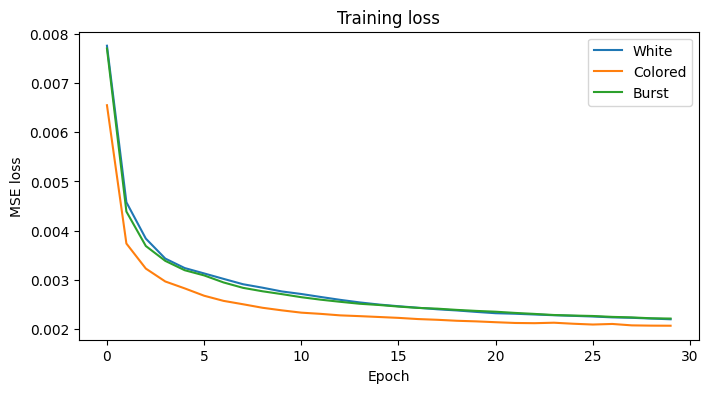

Demo file: /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech/LibriSpeech/test-clean/1089/134686/1089-134686-0000.flac
Demo length (sec): 10.0

2-bit model switch signals sent by encoder:
  segment_1: 00
  segment_2: 01
  segment_3: 10

Saved files:
  outputs/original_demo.wav
  outputs/fixed_white_model_reconstruction.wav
  outputs/adaptive_switching_reconstruction.wav

Original clip:


Fixed white-noise-trained model on mixed channel:


Adaptive switching model on mixed channel:


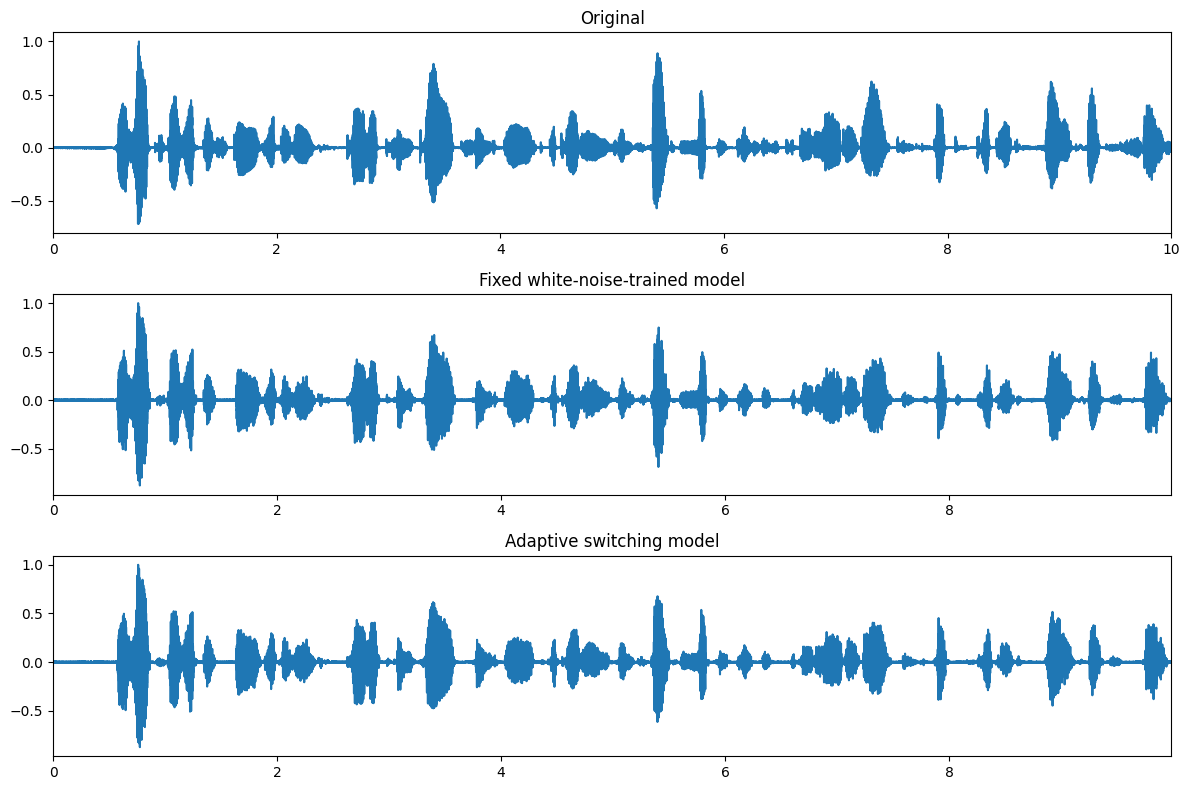

In [9]:
import os
import math
import random
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 0. Reproducibility
# ============================================================

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# In Colab, set Runtime -> Change runtime type -> T4 GPU (or similar)
# Then this will use it automatically if available.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# ============================================================
# 1. Paths and basic settings
# ============================================================

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_ROOT = Path("/content")
else:
    DATA_ROOT = Path.cwd() / "data" / "librispeech"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

LIBRISPEECH_ARCHIVES = {
    "dev-clean.tar.gz": "https://www.openslr.org/resources/12/dev-clean.tar.gz",
    "test-clean.tar.gz": "https://www.openslr.org/resources/12/test-clean.tar.gz",
}


def _is_valid_gzip(path: Path) -> bool:
    try:
        with path.open("rb") as f:
            return f.read(2) == b"\x1f\x8b"
    except OSError:
        return False


def _download(url: str, dest: Path) -> None:
    print(f"Downloading {dest.name} from OpenSLR (may take several minutes)...")
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.replace(dest)


def ensure_librispeech() -> None:
    existing = sorted(DATA_ROOT.rglob("*.flac"))
    if any("dev-clean" in str(p) for p in existing) and any(
        "test-clean" in str(p) for p in existing
    ):
        print("LibriSpeech audio already present under", DATA_ROOT)
        return

    for name, url in LIBRISPEECH_ARCHIVES.items():
        dest = DATA_ROOT / name
        if dest.exists() and not _is_valid_gzip(dest):
            print("Removing invalid archive:", dest)
            dest.unlink(missing_ok=True)
        if not dest.exists():
            _download(url, dest)
        if not _is_valid_gzip(dest):
            raise RuntimeError(
                f"{dest} is not a valid gzip file. Remove it and retry with a stable network."
            )

    for name in LIBRISPEECH_ARCHIVES:
        dest = DATA_ROOT / name
        print("Extracting", dest)
        try:
            with tarfile.open(dest, "r:gz") as tar:
                tar.extractall(path=str(DATA_ROOT))
        except (tarfile.ReadError, OSError, EOFError) as e:
            dest.unlink(missing_ok=True)
            raise RuntimeError(
                f"Failed to extract {dest}: {e!r}. Removed corrupt file; re-run to re-download."
            ) from e


ensure_librispeech()

all_flac = sorted(DATA_ROOT.rglob("*.flac"))

dev_clean_files = [p for p in all_flac if "dev-clean" in str(p)]
test_clean_files = [p for p in all_flac if "test-clean" in str(p)]

print("Found dev-clean files:", len(dev_clean_files))
print("Found test-clean files:", len(test_clean_files))

if len(dev_clean_files) == 0 or len(test_clean_files) == 0:
    raise ValueError("No LibriSpeech .flac files found after extraction.")

TARGET_SR = 16000

# Frame settings
FRAME_SIZE = 512
HOP_SIZE = 512   # non-overlapping for simplicity

# Training subset size
MAX_TRAIN_FILES = 800
MAX_TEST_FILES = 200

# Autoencoder settings
LATENT_DIM = 64
BATCH_SIZE = 256
EPOCHS = 30
LEARNING_RATE = 1e-3

# 10 second demo clip
DEMO_SECONDS = 10

# ============================================================
# 2. Audio utilities
# ============================================================

def normalize_audio(x: np.ndarray) -> np.ndarray:
    peak = np.max(np.abs(x))
    if peak < 1e-8:
        return x.astype(np.float32)
    return (x / peak).astype(np.float32)


def load_wav(path: Path, target_sr: int = 16000) -> np.ndarray:
    """
    Loads a wav/flac file. LibriSpeech is already 16 kHz, mono.
    """
    audio, sr = sf.read(str(path))
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if sr != target_sr:
        raise ValueError(f"{path} has sample rate {sr}, expected {target_sr}")

    return normalize_audio(audio)


def find_audio_files(roots):
    files = []
    for root in roots:
        if root.exists():
            files.extend(root.rglob("*.flac"))
            files.extend(root.rglob("*.wav"))
    return sorted(files)


def pick_training_subset(files, max_files=80, min_seconds=3.0):
    """
    Choose a manageable subset of files.
    """
    chosen = []
    for path in files:
        try:
            audio = load_wav(path, TARGET_SR)
            seconds = len(audio) / TARGET_SR
            if seconds >= min_seconds:
                chosen.append(path)
        except Exception:
            continue
        if len(chosen) >= max_files:
            break
    return chosen


def frame_audio(audio: np.ndarray, frame_size=512, hop_size=512) -> np.ndarray:
    """
    Split a 1D waveform into frames of shape [num_frames, frame_size].
    Drops the tail if needed.
    """
    n = len(audio)
    frames = []
    for start in range(0, n - frame_size + 1, hop_size):
        frame = audio[start:start + frame_size]
        frames.append(frame)
    if not frames:
        return np.zeros((0, frame_size), dtype=np.float32)
    return np.stack(frames).astype(np.float32)


def overlap_add(frames: np.ndarray, hop_size=512) -> np.ndarray:
    """
    Reconstruct waveform from frames.
    For non-overlapping frames, this is just concatenation.
    """
    if len(frames) == 0:
        return np.array([], dtype=np.float32)

    frame_size = frames.shape[1]
    total_len = hop_size * (len(frames) - 1) + frame_size
    output = np.zeros(total_len, dtype=np.float32)
    weight = np.zeros(total_len, dtype=np.float32)

    for i, frame in enumerate(frames):
        start = i * hop_size
        end = start + frame_size
        output[start:end] += frame
        weight[start:end] += 1.0

    weight[weight == 0] = 1.0
    output = output / weight
    return normalize_audio(output)


def crop_to_seconds(audio: np.ndarray, sr: int, seconds: int) -> np.ndarray:
    n = sr * seconds
    if len(audio) >= n:
        return audio[:n]
    out = np.zeros(n, dtype=np.float32)
    out[:len(audio)] = audio
    return out


# ============================================================
# 3. Channel models (noise added in latent/code)
# ============================================================

def add_white_gaussian_noise(z: torch.Tensor, sigma=0.25) -> torch.Tensor:
    noise = sigma * torch.randn_like(z)
    return z + noise


def add_colored_gaussian_noise(z: torch.Tensor, sigma=0.25, alpha=0.9) -> torch.Tensor:
    """
    Correlated Gaussian noise across latent dimension.
    Simple AR(1)-like correlation along the latent axis.
    """
    eps = sigma * torch.randn_like(z)
    colored = torch.zeros_like(z)
    colored[:, 0] = eps[:, 0]
    for i in range(1, z.shape[1]):
        colored[:, i] = alpha * colored[:, i - 1] + math.sqrt(1 - alpha**2) * eps[:, i]
    return z + colored


def add_burst_noise(z: torch.Tensor, burst_prob=0.08, burst_scale=1.0) -> torch.Tensor:
    """
    Sparse impulsive noise in latent space.
    """
    mask = (torch.rand_like(z) < burst_prob).float()
    bursts = burst_scale * torch.randn_like(z) * mask
    return z + bursts


# ============================================================
# 4. Dataset
# ============================================================

class FrameDataset(Dataset):
    def __init__(self, file_paths, frame_size=512, hop_size=512):
        frames = []
        for path in file_paths:
            audio = load_wav(path, TARGET_SR)
            x = frame_audio(audio, frame_size, hop_size)
            if len(x) > 0:
                frames.append(x)

        if not frames:
            raise ValueError("No training frames found.")

        self.frames = np.concatenate(frames, axis=0).astype(np.float32)
        print(f"Built dataset with {len(self.frames)} frames.")

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        x = self.frames[idx]
        return torch.from_numpy(x)


# ============================================================
# 5. Communication autoencoder
# ============================================================

class CommAutoencoder(nn.Module):
    def __init__(self, input_dim=512, latent_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Tanh(),   # waveform frames are normalized roughly to [-1, 1]
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, channel_fn):
        z = self.encode(x)
        z_noisy = channel_fn(z)
        x_hat = self.decode(z_noisy)
        return x_hat


# ============================================================
# 6. Training
# ============================================================

def train_model(model, loader, channel_fn, epochs=10, lr=1e-3, name="model"):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x in loader:
            x = x.to(DEVICE)

            optimizer.zero_grad()
            x_hat = model(x, channel_fn)
            loss = loss_fn(x_hat, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        avg_loss = total_loss / len(loader.dataset)
        history.append(avg_loss)
        print(f"{name} | epoch {epoch + 1:02d}/{epochs} | loss = {avg_loss:.6f}")

    return history


# ============================================================
# 7. Inference helpers
# ============================================================

def run_fixed_model_on_mixed_clip(
    model,
    audio: np.ndarray,
    frame_size=512,
    hop_size=512,
):
    """
    Use one fixed model for the whole clip while the channel changes over time:
    first third white, second third colored, third third burst.
    """
    model.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    n = x.shape[0]
    a = n // 3
    b = 2 * n // 3

    with torch.no_grad():
        z = model.encode(x)

        z_noisy = z.clone()
        z_noisy[:a] = add_white_gaussian_noise(z[:a])
        z_noisy[a:b] = add_colored_gaussian_noise(z[a:b])
        z_noisy[b:] = add_burst_noise(z[b:])

        x_hat = model.decode(z_noisy).cpu().numpy()

    return overlap_add(x_hat, hop_size=hop_size)


def run_adaptive_model_on_mixed_clip(
    models,
    audio: np.ndarray,
    frame_size=512,
    hop_size=512,
):
    """
    Adaptive transmission:
    - first third uses white model
    - second third uses colored model
    - third third uses burst model

    We also simulate a 2-bit model-switch signal.
    Here we only count it / print it; for this demo we assume it arrives perfectly.
    """
    white_model, colored_model, burst_model = models
    for m in models:
        m.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    n = x.shape[0]
    a = n // 3
    b = 2 * n // 3

    # Two-bit model IDs:
    # 00 = white
    # 01 = colored
    # 10 = burst
    switch_headers = [
        ("segment_1", "00"),
        ("segment_2", "01"),
        ("segment_3", "10"),
    ]

    with torch.no_grad():
        out = torch.zeros_like(x)

        # Segment 1
        z1 = white_model.encode(x[:a])
        r1 = add_white_gaussian_noise(z1)
        out[:a] = white_model.decode(r1)

        # Segment 2
        z2 = colored_model.encode(x[a:b])
        r2 = add_colored_gaussian_noise(z2)
        out[a:b] = colored_model.decode(r2)

        # Segment 3
        z3 = burst_model.encode(x[b:])
        r3 = add_burst_noise(z3)
        out[b:] = burst_model.decode(r3)

        out = out.cpu().numpy()

    return overlap_add(out, hop_size=hop_size), switch_headers


# ============================================================
# 8. Build training data
# ============================================================

train_files = pick_training_subset(dev_clean_files, max_files=MAX_TRAIN_FILES)
test_files = pick_training_subset(test_clean_files, max_files=MAX_TEST_FILES)

print(f"Train files selected: {len(train_files)}")
print(f"Test files selected:  {len(test_files)}")

if len(train_files) == 0:
    raise ValueError("No usable training files found.")
if len(test_files) == 0:
    raise ValueError("No usable test files found.")

train_dataset = FrameDataset(train_files, FRAME_SIZE, HOP_SIZE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)


# ============================================================
# 9. Train three specialist autoencoders
# ============================================================

white_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)
colored_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)
burst_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)

print("\nTraining white Gaussian model...")
white_history = train_model(
    white_model,
    train_loader,
    channel_fn=lambda z: add_white_gaussian_noise(z, sigma=0.25),
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="white"
)

print("\nTraining colored Gaussian model...")
colored_history = train_model(
    colored_model,
    train_loader,
    channel_fn=lambda z: add_colored_gaussian_noise(z, sigma=0.25, alpha=0.9),
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="colored"
)

print("\nTraining burst-noise model...")
burst_history = train_model(
    burst_model,
    train_loader,
    channel_fn=lambda z: add_burst_noise(z, burst_prob=0.08, burst_scale=1.0),
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="burst"
)


# ============================================================
# 10. Plot training curves
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(white_history, label="White")
plt.plot(colored_history, label="Colored")
plt.plot(burst_history, label="Burst")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.legend()
plt.show()


# ============================================================
# 11. Prepare 10 second test clip
# ============================================================

def choose_demo_clip(test_files, seconds=10):
    for path in test_files:
        audio = load_wav(path, TARGET_SR)
        if len(audio) >= seconds * TARGET_SR:
            return crop_to_seconds(audio, TARGET_SR, seconds), path

    # If no file is long enough, use the first one and pad
    audio = load_wav(test_files[0], TARGET_SR)
    return crop_to_seconds(audio, TARGET_SR, seconds), test_files[0]


demo_audio, demo_path = choose_demo_clip(test_files, DEMO_SECONDS)
print("Demo file:", demo_path)
print("Demo length (sec):", len(demo_audio) / TARGET_SR)


# ============================================================
# 12. Run the two evaluation conditions
# ============================================================

# 1) Fixed model: use the white-noise-trained model the whole time
fixed_recon = run_fixed_model_on_mixed_clip(
    white_model.to(DEVICE),
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

# 2) Adaptive model: switch at the right times
adaptive_recon, switch_headers = run_adaptive_model_on_mixed_clip(
    [
        white_model.to(DEVICE),
        colored_model.to(DEVICE),
        burst_model.to(DEVICE),
    ],
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

print("\n2-bit model switch signals sent by encoder:")
for seg, bits in switch_headers:
    print(f"  {seg}: {bits}")


# ============================================================
# 13. Save outputs
# ============================================================

os.makedirs("outputs", exist_ok=True)

sf.write("outputs/original_demo.wav", demo_audio, TARGET_SR)
sf.write("outputs/fixed_white_model_reconstruction.wav", fixed_recon, TARGET_SR)
sf.write("outputs/adaptive_switching_reconstruction.wav", adaptive_recon, TARGET_SR)

print("\nSaved files:")
print("  outputs/original_demo.wav")
print("  outputs/fixed_white_model_reconstruction.wav")
print("  outputs/adaptive_switching_reconstruction.wav")


# ============================================================
# 14. Listen to the three clips
# ============================================================

print("\nOriginal clip:")
display(Audio(demo_audio, rate=TARGET_SR))

print("Fixed white-noise-trained model on mixed channel:")
display(Audio(fixed_recon, rate=TARGET_SR))

print("Adaptive switching model on mixed channel:")
display(Audio(adaptive_recon, rate=TARGET_SR))


# ============================================================
# 15. Quick waveform plot
# ============================================================

def plot_waveforms(original, fixed, adaptive, sr=16000):
    t1 = np.arange(len(original)) / sr
    t2 = np.arange(len(fixed)) / sr
    t3 = np.arange(len(adaptive)) / sr

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t1, original)
    plt.title("Original")
    plt.xlim([0, len(original) / sr])

    plt.subplot(3, 1, 2)
    plt.plot(t2, fixed)
    plt.title("Fixed white-noise-trained model")
    plt.xlim([0, len(fixed) / sr])

    plt.subplot(3, 1, 3)
    plt.plot(t3, adaptive)
    plt.title("Adaptive switching model")
    plt.xlim([0, len(adaptive) / sr])

    plt.tight_layout()
    plt.show()

plot_waveforms(demo_audio, fixed_recon, adaptive_recon, TARGET_SR)


# Update with harsher noise

Using device: cpu
LibriSpeech audio already present under /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech
Found dev-clean files: 2703
Found test-clean files: 2620
Train files selected: 800
Test files selected:  200
Built dataset with 197388 frames.

Training white Gaussian model...
white | epoch 01/30 | loss = 0.007763
white | epoch 02/30 | loss = 0.004576
white | epoch 03/30 | loss = 0.003836
white | epoch 04/30 | loss = 0.003429
white | epoch 05/30 | loss = 0.003236
white | epoch 06/30 | loss = 0.003127
white | epoch 07/30 | loss = 0.003016
white | epoch 08/30 | loss = 0.002907
white | epoch 09/30 | loss = 0.002837
white | epoch 10/30 | loss = 0.002760
white | epoch 11/30 | loss = 0.002708
white | epoch 12/30 | loss = 0.002647
white | epoch 13/30 | loss = 0.002589
white | epoch 14/30 | loss = 0.002537
white | epoch 15/30 | loss = 0.002493
white | epoch 16/30 | loss = 0.002459
white | epoch 17/30 | loss = 0.002428
white | epoch 18/30 | loss = 0.002397
white |

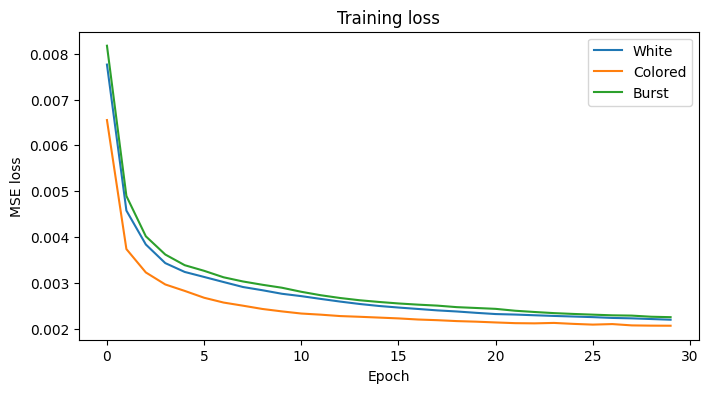

Demo file: /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech/LibriSpeech/test-clean/1089/134686/1089-134686-0000.flac
Demo length (sec): 10.0

2-bit model switch signals sent by encoder:
  segment_1: 00
  segment_2: 01
  segment_3: 10

Saved files:
  outputs/original_demo.wav
  outputs/fixed_white_model_reconstruction.wav
  outputs/adaptive_switching_reconstruction.wav

Original clip:


Fixed white-noise-trained model on mixed channel:


Adaptive switching model on mixed channel:


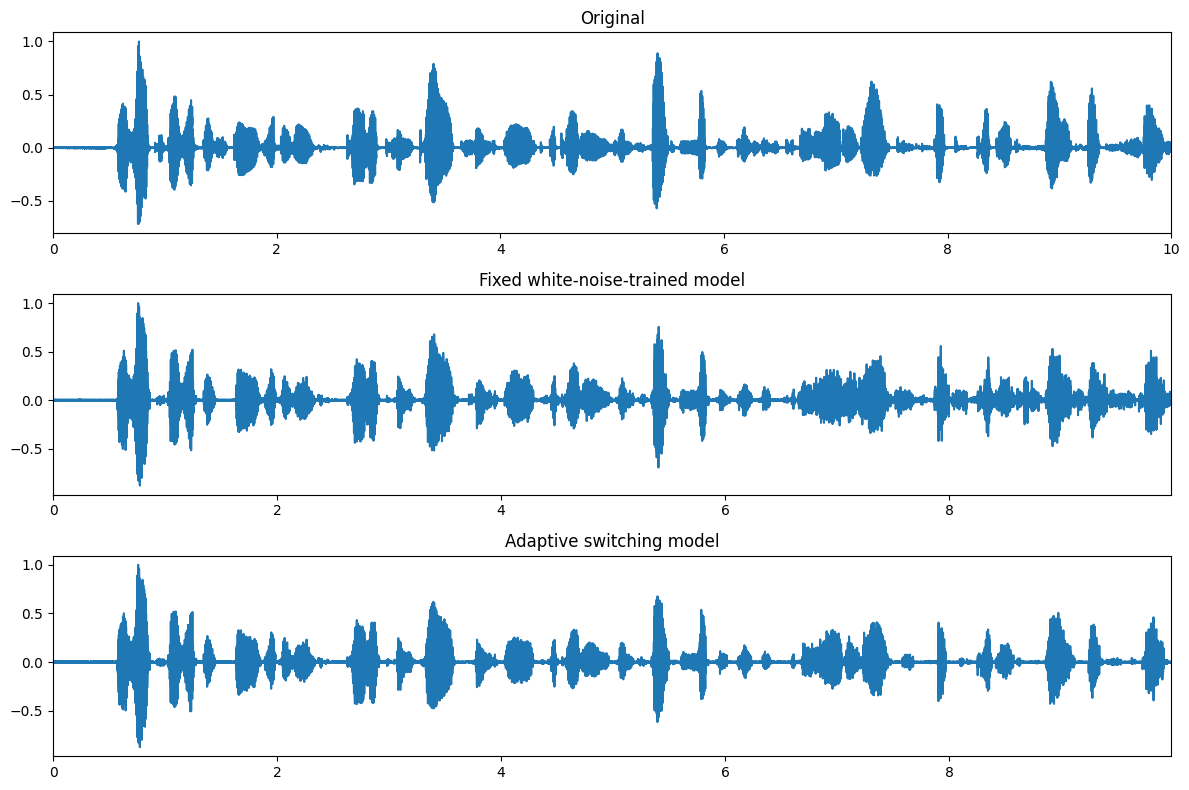

In [10]:
import os
import math
import random
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 0. Reproducibility
# ============================================================

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# In Colab, set Runtime -> Change runtime type -> T4 GPU (or similar)
# Then this will use it automatically if available.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# ============================================================
# 1. Paths and basic settings
# ============================================================

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_ROOT = Path("/content")
else:
    DATA_ROOT = Path.cwd() / "data" / "librispeech"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

LIBRISPEECH_ARCHIVES = {
    "dev-clean.tar.gz": "https://www.openslr.org/resources/12/dev-clean.tar.gz",
    "test-clean.tar.gz": "https://www.openslr.org/resources/12/test-clean.tar.gz",
}


def _is_valid_gzip(path: Path) -> bool:
    try:
        with path.open("rb") as f:
            return f.read(2) == b"\x1f\x8b"
    except OSError:
        return False


def _download(url: str, dest: Path) -> None:
    print(f"Downloading {dest.name} from OpenSLR (may take several minutes)...")
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.replace(dest)


def ensure_librispeech() -> None:
    existing = sorted(DATA_ROOT.rglob("*.flac"))
    if any("dev-clean" in str(p) for p in existing) and any(
        "test-clean" in str(p) for p in existing
    ):
        print("LibriSpeech audio already present under", DATA_ROOT)
        return

    for name, url in LIBRISPEECH_ARCHIVES.items():
        dest = DATA_ROOT / name
        if dest.exists() and not _is_valid_gzip(dest):
            print("Removing invalid archive:", dest)
            dest.unlink(missing_ok=True)
        if not dest.exists():
            _download(url, dest)
        if not _is_valid_gzip(dest):
            raise RuntimeError(
                f"{dest} is not a valid gzip file. Remove it and retry with a stable network."
            )

    for name in LIBRISPEECH_ARCHIVES:
        dest = DATA_ROOT / name
        print("Extracting", dest)
        try:
            with tarfile.open(dest, "r:gz") as tar:
                tar.extractall(path=str(DATA_ROOT))
        except (tarfile.ReadError, OSError, EOFError) as e:
            dest.unlink(missing_ok=True)
            raise RuntimeError(
                f"Failed to extract {dest}: {e!r}. Removed corrupt file; re-run to re-download."
            ) from e


ensure_librispeech()

all_flac = sorted(DATA_ROOT.rglob("*.flac"))

dev_clean_files = [p for p in all_flac if "dev-clean" in str(p)]
test_clean_files = [p for p in all_flac if "test-clean" in str(p)]

print("Found dev-clean files:", len(dev_clean_files))
print("Found test-clean files:", len(test_clean_files))

if len(dev_clean_files) == 0 or len(test_clean_files) == 0:
    raise ValueError("No LibriSpeech .flac files found after extraction.")

TARGET_SR = 16000

# Frame settings
FRAME_SIZE = 512
HOP_SIZE = 512   # non-overlapping for simplicity

# Training subset size
MAX_TRAIN_FILES = 800
MAX_TEST_FILES = 200

# Autoencoder settings
LATENT_DIM = 64
BATCH_SIZE = 256
EPOCHS = 30
LEARNING_RATE = 1e-3

# 10 second demo clip
DEMO_SECONDS = 10

# ============================================================
# 2. Audio utilities
# ============================================================

def normalize_audio(x: np.ndarray) -> np.ndarray:
    peak = np.max(np.abs(x))
    if peak < 1e-8:
        return x.astype(np.float32)
    return (x / peak).astype(np.float32)


def load_wav(path: Path, target_sr: int = 16000) -> np.ndarray:
    """
    Loads a wav/flac file. LibriSpeech is already 16 kHz, mono.
    """
    audio, sr = sf.read(str(path))
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if sr != target_sr:
        raise ValueError(f"{path} has sample rate {sr}, expected {target_sr}")

    return normalize_audio(audio)


def find_audio_files(roots):
    files = []
    for root in roots:
        if root.exists():
            files.extend(root.rglob("*.flac"))
            files.extend(root.rglob("*.wav"))
    return sorted(files)


def pick_training_subset(files, max_files=80, min_seconds=3.0):
    """
    Choose a manageable subset of files.
    """
    chosen = []
    for path in files:
        try:
            audio = load_wav(path, TARGET_SR)
            seconds = len(audio) / TARGET_SR
            if seconds >= min_seconds:
                chosen.append(path)
        except Exception:
            continue
        if len(chosen) >= max_files:
            break
    return chosen


def frame_audio(audio: np.ndarray, frame_size=512, hop_size=512) -> np.ndarray:
    """
    Split a 1D waveform into frames of shape [num_frames, frame_size].
    Drops the tail if needed.
    """
    n = len(audio)
    frames = []
    for start in range(0, n - frame_size + 1, hop_size):
        frame = audio[start:start + frame_size]
        frames.append(frame)
    if not frames:
        return np.zeros((0, frame_size), dtype=np.float32)
    return np.stack(frames).astype(np.float32)


def overlap_add(frames: np.ndarray, hop_size=512) -> np.ndarray:
    """
    Reconstruct waveform from frames.
    For non-overlapping frames, this is just concatenation.
    """
    if len(frames) == 0:
        return np.array([], dtype=np.float32)

    frame_size = frames.shape[1]
    total_len = hop_size * (len(frames) - 1) + frame_size
    output = np.zeros(total_len, dtype=np.float32)
    weight = np.zeros(total_len, dtype=np.float32)

    for i, frame in enumerate(frames):
        start = i * hop_size
        end = start + frame_size
        output[start:end] += frame
        weight[start:end] += 1.0

    weight[weight == 0] = 1.0
    output = output / weight
    return normalize_audio(output)


def crop_to_seconds(audio: np.ndarray, sr: int, seconds: int) -> np.ndarray:
    n = sr * seconds
    if len(audio) >= n:
        return audio[:n]
    out = np.zeros(n, dtype=np.float32)
    out[:len(audio)] = audio
    return out


# ============================================================
# 3. Channel models (noise added in latent/code)
# ============================================================

def add_white_gaussian_noise(z: torch.Tensor, sigma=0.18) -> torch.Tensor:
    noise = sigma * torch.randn_like(z)
    return z + noise

def add_colored_gaussian_noise(z: torch.Tensor, sigma=0.45, alpha=0.98) -> torch.Tensor:
    eps = sigma * torch.randn_like(z)
    colored = torch.zeros_like(z)
    colored[:, 0] = eps[:, 0]
    for i in range(1, z.shape[1]):
        colored[:, i] = alpha * colored[:, i - 1] + math.sqrt(1 - alpha**2) * eps[:, i]
    return z + colored

def add_burst_noise(z: torch.Tensor, burst_prob=0.12, burst_scale=2.5) -> torch.Tensor:
    mask = (torch.rand_like(z) < burst_prob).float()
    laplace = torch.distributions.Laplace(
        torch.tensor(0.0, device=z.device),
        torch.tensor(burst_scale, device=z.device)
    )
    bursts = laplace.sample(z.shape) * mask
    return z + bursts

def train_white_channel(z):
    return add_white_gaussian_noise(z, sigma=0.18)

def train_colored_channel(z):
    return add_colored_gaussian_noise(z, sigma=0.30, alpha=0.95)

def train_burst_channel(z):
    return add_burst_noise(z, burst_prob=0.08, burst_scale=1.2)

def test_white_channel(z):
    return add_white_gaussian_noise(z, sigma=0.20)

def test_colored_channel(z):
    return add_colored_gaussian_noise(z, sigma=0.45, alpha=0.98)

def test_burst_channel(z):
    return add_burst_noise(z, burst_prob=0.15, burst_scale=2.0)

# ============================================================
# 4. Dataset
# ============================================================

class FrameDataset(Dataset):
    def __init__(self, file_paths, frame_size=512, hop_size=512):
        frames = []
        for path in file_paths:
            audio = load_wav(path, TARGET_SR)
            x = frame_audio(audio, frame_size, hop_size)
            if len(x) > 0:
                frames.append(x)

        if not frames:
            raise ValueError("No training frames found.")

        self.frames = np.concatenate(frames, axis=0).astype(np.float32)
        print(f"Built dataset with {len(self.frames)} frames.")

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        x = self.frames[idx]
        return torch.from_numpy(x)


# ============================================================
# 5. Communication autoencoder
# ============================================================

class CommAutoencoder(nn.Module):
    def __init__(self, input_dim=512, latent_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Tanh(),   # waveform frames are normalized roughly to [-1, 1]
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, channel_fn):
        z = self.encode(x)
        z_noisy = channel_fn(z)
        x_hat = self.decode(z_noisy)
        return x_hat


# ============================================================
# 6. Training
# ============================================================

def train_model(model, loader, channel_fn, epochs=10, lr=1e-3, name="model"):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x in loader:
            x = x.to(DEVICE)

            optimizer.zero_grad()
            x_hat = model(x, channel_fn)
            loss = loss_fn(x_hat, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        avg_loss = total_loss / len(loader.dataset)
        history.append(avg_loss)
        print(f"{name} | epoch {epoch + 1:02d}/{epochs} | loss = {avg_loss:.6f}")

    return history


# ============================================================
# 7. Inference helpers
# ============================================================

def run_fixed_model_on_mixed_clip(
    model,
    audio: np.ndarray,
    frame_size=512,
    hop_size=512,
):
    """
    Use one fixed model for the whole clip while the channel changes over time:
    first third white, second third colored, third third burst.
    """
    model.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    n = x.shape[0]
    a = n // 3
    b = 2 * n // 3

    with torch.no_grad():
        z = model.encode(x)

        z_noisy = z.clone()
        z_noisy[:a] = add_white_gaussian_noise(z[:a])
        z_noisy[a:b] = add_colored_gaussian_noise(z[a:b])
        z_noisy[b:] = add_burst_noise(z[b:])

        x_hat = model.decode(z_noisy).cpu().numpy()

    return overlap_add(x_hat, hop_size=hop_size)


def run_adaptive_model_on_mixed_clip(
    models,
    audio: np.ndarray,
    frame_size=512,
    hop_size=512,
):
    """
    Adaptive transmission:
    - first third uses white model
    - second third uses colored model
    - third third uses burst model

    We also simulate a 2-bit model-switch signal.
    Here we only count it / print it; for this demo we assume it arrives perfectly.
    """
    white_model, colored_model, burst_model = models
    for m in models:
        m.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    n = x.shape[0]
    a = n // 3
    b = 2 * n // 3

    # Two-bit model IDs:
    # 00 = white
    # 01 = colored
    # 10 = burst
    switch_headers = [
        ("segment_1", "00"),
        ("segment_2", "01"),
        ("segment_3", "10"),
    ]

    with torch.no_grad():
        out = torch.zeros_like(x)

        # Segment 1
        z1 = white_model.encode(x[:a])
        r1 = add_white_gaussian_noise(z1)
        out[:a] = white_model.decode(r1)

        # Segment 2
        z2 = colored_model.encode(x[a:b])
        r2 = add_colored_gaussian_noise(z2)
        out[a:b] = colored_model.decode(r2)

        # Segment 3
        z3 = burst_model.encode(x[b:])
        r3 = add_burst_noise(z3)
        out[b:] = burst_model.decode(r3)

        out = out.cpu().numpy()

    return overlap_add(out, hop_size=hop_size), switch_headers


# ============================================================
# 8. Build training data
# ============================================================

train_files = pick_training_subset(dev_clean_files, max_files=MAX_TRAIN_FILES)
test_files = pick_training_subset(test_clean_files, max_files=MAX_TEST_FILES)

print(f"Train files selected: {len(train_files)}")
print(f"Test files selected:  {len(test_files)}")

if len(train_files) == 0:
    raise ValueError("No usable training files found.")
if len(test_files) == 0:
    raise ValueError("No usable test files found.")

train_dataset = FrameDataset(train_files, FRAME_SIZE, HOP_SIZE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)


# ============================================================
# 9. Train three specialist autoencoders
# ============================================================

white_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)
colored_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)
burst_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)

print("\nTraining white Gaussian model...")
white_history = train_model(
    white_model,
    train_loader,
    channel_fn=lambda z: add_white_gaussian_noise(z, sigma=0.25),
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="white"
)

print("\nTraining colored Gaussian model...")
colored_history = train_model(
    colored_model,
    train_loader,
    channel_fn=lambda z: add_colored_gaussian_noise(z, sigma=0.25, alpha=0.9),
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="colored"
)

print("\nTraining burst-noise model...")
burst_history = train_model(
    burst_model,
    train_loader,
    channel_fn=lambda z: add_burst_noise(z, burst_prob=0.08, burst_scale=1.0),
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="burst"
)


# ============================================================
# 10. Plot training curves
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(white_history, label="White")
plt.plot(colored_history, label="Colored")
plt.plot(burst_history, label="Burst")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.legend()
plt.show()


# ============================================================
# 11. Prepare 10 second test clip
# ============================================================

def choose_demo_clip(test_files, seconds=10):
    for path in test_files:
        audio = load_wav(path, TARGET_SR)
        if len(audio) >= seconds * TARGET_SR:
            return crop_to_seconds(audio, TARGET_SR, seconds), path

    # If no file is long enough, use the first one and pad
    audio = load_wav(test_files[0], TARGET_SR)
    return crop_to_seconds(audio, TARGET_SR, seconds), test_files[0]


demo_audio, demo_path = choose_demo_clip(test_files, DEMO_SECONDS)
print("Demo file:", demo_path)
print("Demo length (sec):", len(demo_audio) / TARGET_SR)


# ============================================================
# 12. Run the two evaluation conditions
# ============================================================

# 1) Fixed model: use the white-noise-trained model the whole time
fixed_recon = run_fixed_model_on_mixed_clip(
    white_model.to(DEVICE),
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

# 2) Adaptive model: switch at the right times
adaptive_recon, switch_headers = run_adaptive_model_on_mixed_clip(
    [
        white_model.to(DEVICE),
        colored_model.to(DEVICE),
        burst_model.to(DEVICE),
    ],
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

print("\n2-bit model switch signals sent by encoder:")
for seg, bits in switch_headers:
    print(f"  {seg}: {bits}")


# ============================================================
# 13. Save outputs
# ============================================================

os.makedirs("outputs", exist_ok=True)

sf.write("outputs/original_demo.wav", demo_audio, TARGET_SR)
sf.write("outputs/fixed_white_model_reconstruction.wav", fixed_recon, TARGET_SR)
sf.write("outputs/adaptive_switching_reconstruction.wav", adaptive_recon, TARGET_SR)

print("\nSaved files:")
print("  outputs/original_demo.wav")
print("  outputs/fixed_white_model_reconstruction.wav")
print("  outputs/adaptive_switching_reconstruction.wav")


# ============================================================
# 14. Listen to the three clips
# ============================================================

print("\nOriginal clip:")
display(Audio(demo_audio, rate=TARGET_SR))

print("Fixed white-noise-trained model on mixed channel:")
display(Audio(fixed_recon, rate=TARGET_SR))

print("Adaptive switching model on mixed channel:")
display(Audio(adaptive_recon, rate=TARGET_SR))


# ============================================================
# 15. Quick waveform plot
# ============================================================

def plot_waveforms(original, fixed, adaptive, sr=16000):
    t1 = np.arange(len(original)) / sr
    t2 = np.arange(len(fixed)) / sr
    t3 = np.arange(len(adaptive)) / sr

    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(t1, original)
    plt.title("Original")
    plt.xlim([0, len(original) / sr])

    plt.subplot(3, 1, 2)
    plt.plot(t2, fixed)
    plt.title("Fixed white-noise-trained model")
    plt.xlim([0, len(fixed) / sr])

    plt.subplot(3, 1, 3)
    plt.plot(t3, adaptive)
    plt.title("Adaptive switching model")
    plt.xlim([0, len(adaptive) / sr])

    plt.tight_layout()
    plt.show()

plot_waveforms(demo_audio, fixed_recon, adaptive_recon, TARGET_SR)


# Easier Training Conditions

Using device: cpu
LibriSpeech audio already present under /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech
Found dev-clean files: 2703
Found test-clean files: 2620
Train files selected: 1200
Test files selected:  300
Built dataset with 310608 frames.

Training white Gaussian model...
white | epoch 01/20 | loss = 0.005096
white | epoch 02/20 | loss = 0.003114
white | epoch 03/20 | loss = 0.002710
white | epoch 04/20 | loss = 0.002454
white | epoch 05/20 | loss = 0.002269
white | epoch 06/20 | loss = 0.002157
white | epoch 07/20 | loss = 0.002085
white | epoch 08/20 | loss = 0.002020
white | epoch 09/20 | loss = 0.002003
white | epoch 10/20 | loss = 0.001971
white | epoch 11/20 | loss = 0.001937
white | epoch 12/20 | loss = 0.001911
white | epoch 13/20 | loss = 0.001881
white | epoch 14/20 | loss = 0.001867
white | epoch 15/20 | loss = 0.001860
white | epoch 16/20 | loss = 0.001858
white | epoch 17/20 | loss = 0.001855
white | epoch 18/20 | loss = 0.001849
white 

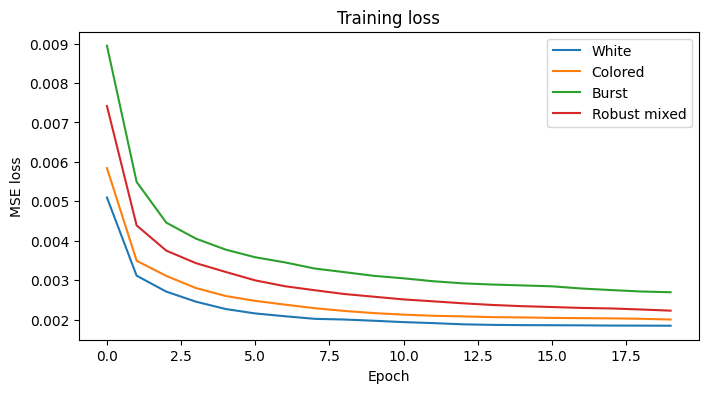

Demo file: /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech/LibriSpeech/test-clean/1188/133604/1188-133604-0009.flac
Demo length (sec): 21.0

2-bit model switch signals sent by encoder:
  segment_1: 00
  segment_2: 01
  segment_3: 10

Saved files:
  outputs/original_demo.wav
  outputs/fixed_white_model_reconstruction.wav
  outputs/adaptive_switching_reconstruction.wav
  outputs/robust_mixed_model_reconstruction.wav

Original clip:


Fixed white-noise-trained model on mixed channel:


Adaptive switching model on mixed channel:


Robust mixed-noise-trained model on mixed channel:


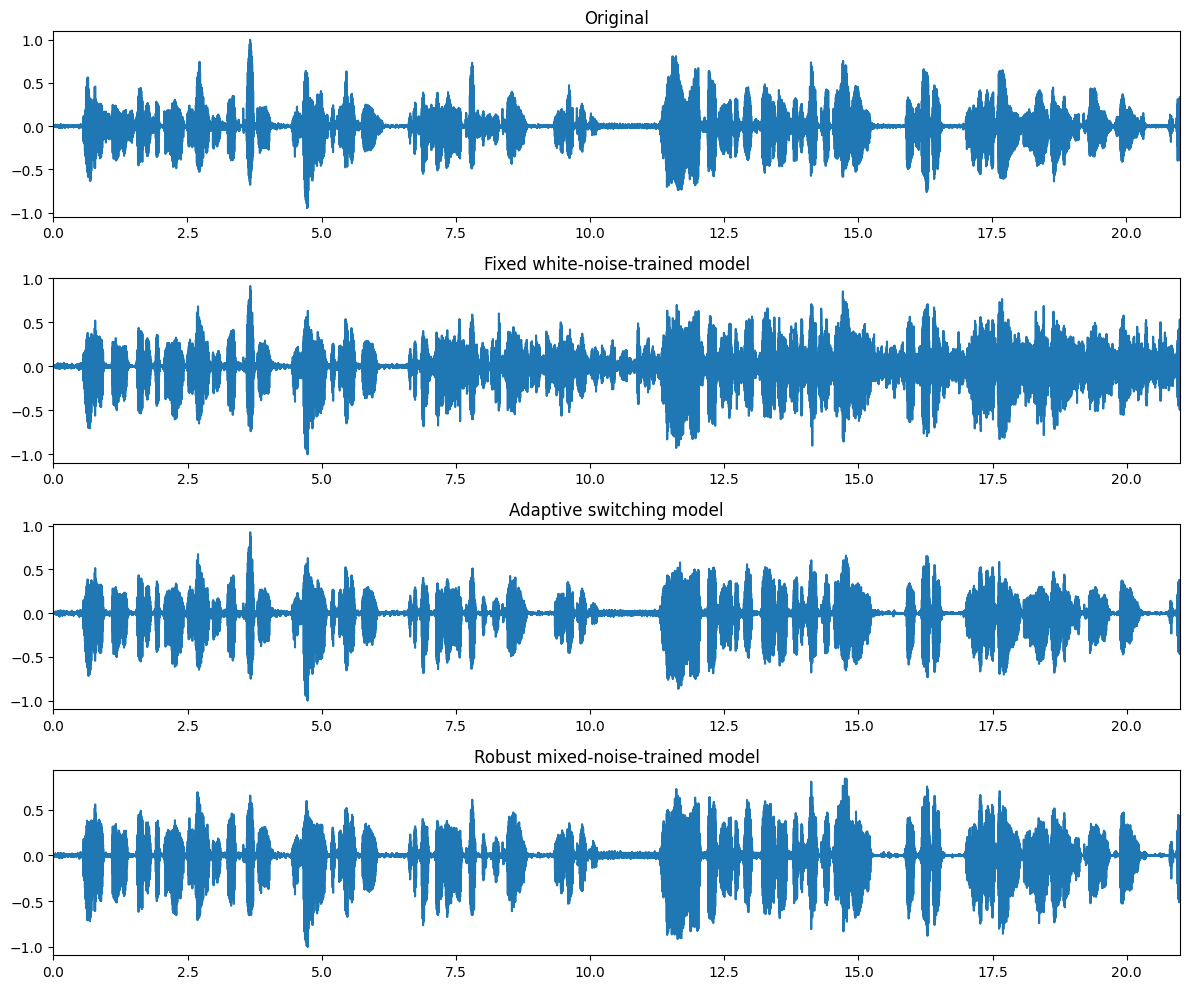

In [11]:
import os
import math
import random
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from IPython.display import Audio, display

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 0. Reproducibility
# ============================================================

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# ============================================================
# 1. Paths and basic settings
# ============================================================

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_ROOT = Path("/content")
else:
    DATA_ROOT = Path.cwd() / "data" / "librispeech"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

LIBRISPEECH_ARCHIVES = {
    "dev-clean.tar.gz": "https://www.openslr.org/resources/12/dev-clean.tar.gz",
    "test-clean.tar.gz": "https://www.openslr.org/resources/12/test-clean.tar.gz",
}


def _is_valid_gzip(path: Path) -> bool:
    try:
        with path.open("rb") as f:
            return f.read(2) == b"\x1f\x8b"
    except OSError:
        return False


def _download(url: str, dest: Path) -> None:
    print(f"Downloading {dest.name} from OpenSLR (may take several minutes)...")
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.replace(dest)


def ensure_librispeech() -> None:
    existing = sorted(DATA_ROOT.rglob("*.flac"))
    if any("dev-clean" in str(p) for p in existing) and any(
        "test-clean" in str(p) for p in existing
    ):
        print("LibriSpeech audio already present under", DATA_ROOT)
        return

    for name, url in LIBRISPEECH_ARCHIVES.items():
        dest = DATA_ROOT / name
        if dest.exists() and not _is_valid_gzip(dest):
            print("Removing invalid archive:", dest)
            dest.unlink(missing_ok=True)
        if not dest.exists():
            _download(url, dest)
        if not _is_valid_gzip(dest):
            raise RuntimeError(
                f"{dest} is not a valid gzip file. Remove it and retry with a stable network."
            )

    for name in LIBRISPEECH_ARCHIVES:
        dest = DATA_ROOT / name
        print("Extracting", dest)
        try:
            with tarfile.open(dest, "r:gz") as tar:
                tar.extractall(path=str(DATA_ROOT))
        except (tarfile.ReadError, OSError, EOFError) as e:
            dest.unlink(missing_ok=True)
            raise RuntimeError(
                f"Failed to extract {dest}: {e!r}. Removed corrupt file; re-run to re-download."
            ) from e


ensure_librispeech()

all_flac = sorted(DATA_ROOT.rglob("*.flac"))

dev_clean_files = [p for p in all_flac if "dev-clean" in str(p)]
test_clean_files = [p for p in all_flac if "test-clean" in str(p)]

print("Found dev-clean files:", len(dev_clean_files))
print("Found test-clean files:", len(test_clean_files))

if len(dev_clean_files) == 0 or len(test_clean_files) == 0:
    raise ValueError("No LibriSpeech .flac files found after extraction.")

TARGET_SR = 16000

FRAME_SIZE = 512
HOP_SIZE = 512

MAX_TRAIN_FILES = 1200
MAX_TEST_FILES = 300

LATENT_DIM = 64
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 1e-3

DEMO_SECONDS = 21


# ============================================================
# 2. Audio utilities
# ============================================================

def normalize_audio(x: np.ndarray) -> np.ndarray:
    peak = np.max(np.abs(x))
    if peak < 1e-8:
        return x.astype(np.float32)
    return (x / peak).astype(np.float32)


def load_wav(path: Path, target_sr: int = 16000) -> np.ndarray:
    audio, sr = sf.read(str(path))
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if sr != target_sr:
        raise ValueError(f"{path} has sample rate {sr}, expected {target_sr}")

    return normalize_audio(audio)


def pick_training_subset(files, max_files=80, min_seconds=3.0):
    chosen = []
    for path in files:
        try:
            audio = load_wav(path, TARGET_SR)
            seconds = len(audio) / TARGET_SR
            if seconds >= min_seconds:
                chosen.append(path)
        except Exception:
            continue
        if len(chosen) >= max_files:
            break
    return chosen


def frame_audio(audio: np.ndarray, frame_size=512, hop_size=512) -> np.ndarray:
    n = len(audio)
    frames = []
    for start in range(0, n - frame_size + 1, hop_size):
        frame = audio[start:start + frame_size]
        frames.append(frame)
    if not frames:
        return np.zeros((0, frame_size), dtype=np.float32)
    return np.stack(frames).astype(np.float32)


def overlap_add(frames: np.ndarray, hop_size=512) -> np.ndarray:
    if len(frames) == 0:
        return np.array([], dtype=np.float32)

    frame_size = frames.shape[1]
    total_len = hop_size * (len(frames) - 1) + frame_size
    output = np.zeros(total_len, dtype=np.float32)
    weight = np.zeros(total_len, dtype=np.float32)

    for i, frame in enumerate(frames):
        start = i * hop_size
        end = start + frame_size
        output[start:end] += frame
        weight[start:end] += 1.0

    weight[weight == 0] = 1.0
    output = output / weight
    return normalize_audio(output)


def crop_to_seconds(audio: np.ndarray, sr: int, seconds: int) -> np.ndarray:
    n = sr * seconds
    if len(audio) >= n:
        return audio[:n]
    out = np.zeros(n, dtype=np.float32)
    out[:len(audio)] = audio
    return out


# ============================================================
# 3. Channel models (noise added in latent/code)
# ============================================================

def add_white_gaussian_noise(z: torch.Tensor, sigma=0.18) -> torch.Tensor:
    noise = sigma * torch.randn_like(z)
    return z + noise


def add_colored_gaussian_noise(z: torch.Tensor, sigma=0.45, alpha=0.98) -> torch.Tensor:
    eps = sigma * torch.randn_like(z)
    colored = torch.zeros_like(z)
    colored[:, 0] = eps[:, 0]
    for i in range(1, z.shape[1]):
        colored[:, i] = alpha * colored[:, i - 1] + math.sqrt(1 - alpha**2) * eps[:, i]
    return z + colored


def add_burst_noise(z: torch.Tensor, burst_prob=0.12, burst_scale=2.5) -> torch.Tensor:
    mask = (torch.rand_like(z) < burst_prob).float()
    laplace = torch.distributions.Laplace(
        torch.tensor(0.0, device=z.device),
        torch.tensor(burst_scale, device=z.device)
    )
    bursts = laplace.sample(z.shape) * mask
    return z + bursts


def train_white_channel(z):
    return add_white_gaussian_noise(z, sigma=0.06)


def train_colored_channel(z):
    return add_colored_gaussian_noise(z, sigma=0.45, alpha=0.97)


def train_burst_channel(z):
    return add_burst_noise(z, burst_prob=0.15, burst_scale=1.35)

def train_mixed_channel(z):
    n = z.shape[0]
    a = n // 3
    b = 2 * n // 3

    z_noisy = z.clone()
    z_noisy[:a] = train_white_channel(z[:a])
    z_noisy[a:b] = train_colored_channel(z[a:b])
    z_noisy[b:] = train_burst_channel(z[b:])

    return z_noisy


def test_white_channel(z):
    return add_white_gaussian_noise(z, sigma=0.08)


def test_colored_channel(z):
    return add_colored_gaussian_noise(z, sigma=0.65, alpha=0.995)


def test_burst_channel(z):
    return add_burst_noise(z, burst_prob=0.15, burst_scale=1.8)


# ============================================================
# 4. Dataset
# ============================================================

class FrameDataset(Dataset):
    def __init__(self, file_paths, frame_size=512, hop_size=512):
        frames = []
        for path in file_paths:
            audio = load_wav(path, TARGET_SR)
            x = frame_audio(audio, frame_size, hop_size)
            if len(x) > 0:
                frames.append(x)

        if not frames:
            raise ValueError("No training frames found.")

        self.frames = np.concatenate(frames, axis=0).astype(np.float32)
        print(f"Built dataset with {len(self.frames)} frames.")

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        x = self.frames[idx]
        return torch.from_numpy(x)


# ============================================================
# 5. Communication autoencoder
# ============================================================

class CommAutoencoder(nn.Module):
    def __init__(self, input_dim=512, latent_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Tanh(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, channel_fn):
        z = self.encode(x)
        z_noisy = channel_fn(z)
        x_hat = self.decode(z_noisy)
        return x_hat


# ============================================================
# 6. Training
# ============================================================

def train_model(model, loader, channel_fn, epochs=10, lr=1e-3, name="model"):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x in loader:
            x = x.to(DEVICE)

            optimizer.zero_grad()
            x_hat = model(x, channel_fn)
            loss = loss_fn(x_hat, x)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        avg_loss = total_loss / len(loader.dataset)
        history.append(avg_loss)
        print(f"{name} | epoch {epoch + 1:02d}/{epochs} | loss = {avg_loss:.6f}")

    return history


# ============================================================
# 7. Inference helpers
# ============================================================

def run_fixed_model_on_mixed_clip(
    model,
    audio: np.ndarray,
    frame_size=512,
    hop_size=512,
):
    model.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    n = x.shape[0]
    a = n // 3
    b = 2 * n // 3

    with torch.no_grad():
        z = model.encode(x)

        z_noisy = z.clone()
        z_noisy[:a] = test_white_channel(z[:a])
        z_noisy[a:b] = test_colored_channel(z[a:b])
        z_noisy[b:] = test_burst_channel(z[b:])

        x_hat = model.decode(z_noisy).cpu().numpy()

    return overlap_add(x_hat, hop_size=hop_size)


def run_adaptive_model_on_mixed_clip(
    models,
    audio: np.ndarray,
    frame_size=512,
    hop_size=512,
):
    white_model, colored_model, burst_model = models
    for m in models:
        m.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    n = x.shape[0]
    a = n // 3
    b = 2 * n // 3

    switch_headers = [
        ("segment_1", "00"),
        ("segment_2", "01"),
        ("segment_3", "10"),
    ]

    with torch.no_grad():
        out = torch.zeros_like(x)

        z1 = white_model.encode(x[:a])
        r1 = test_white_channel(z1)
        out[:a] = white_model.decode(r1)

        z2 = colored_model.encode(x[a:b])
        r2 = test_colored_channel(z2)
        out[a:b] = colored_model.decode(r2)

        z3 = burst_model.encode(x[b:])
        r3 = test_burst_channel(z3)
        out[b:] = burst_model.decode(r3)

        out = out.cpu().numpy()

    return overlap_add(out, hop_size=hop_size), switch_headers


# ============================================================
# 8. Build training data
# ============================================================

train_files = pick_training_subset(dev_clean_files, max_files=MAX_TRAIN_FILES)
test_files = pick_training_subset(test_clean_files, max_files=MAX_TEST_FILES)

print(f"Train files selected: {len(train_files)}")
print(f"Test files selected:  {len(test_files)}")

if len(train_files) == 0:
    raise ValueError("No usable training files found.")
if len(test_files) == 0:
    raise ValueError("No usable test files found.")

train_dataset = FrameDataset(train_files, FRAME_SIZE, HOP_SIZE)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)


# ============================================================
# 9. Train three specialist autoencoders
# ============================================================

white_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)
colored_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)
burst_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)
robust_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)

print("\nTraining white Gaussian model...")
white_history = train_model(
    white_model,
    train_loader,
    channel_fn=train_white_channel,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="white"
)

print("\nTraining colored Gaussian model...")
colored_history = train_model(
    colored_model,
    train_loader,
    channel_fn=train_colored_channel,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="colored"
)

print("\nTraining burst-noise model...")
burst_history = train_model(
    burst_model,
    train_loader,
    channel_fn=train_burst_channel,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="burst"
)

print("\nTraining robust mixed-noise model...")
robust_history = train_model(
    robust_model,
    train_loader,
    channel_fn=train_mixed_channel,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="robust"
)


# ============================================================
# 10. Plot training curves
# ============================================================

plt.figure(figsize=(8, 4))
plt.plot(white_history, label="White")
plt.plot(colored_history, label="Colored")
plt.plot(burst_history, label="Burst")
plt.plot(robust_history, label="Robust mixed")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.legend()
plt.show()


# ============================================================
# 11. Prepare 10 second test clip
# ============================================================

def choose_demo_clip(test_files, seconds=10):
    for path in test_files:
        audio = load_wav(path, TARGET_SR)
        if len(audio) >= seconds * TARGET_SR:
            return crop_to_seconds(audio, TARGET_SR, seconds), path

    audio = load_wav(test_files[0], TARGET_SR)
    return crop_to_seconds(audio, TARGET_SR, seconds), test_files[0]


demo_audio, demo_path = choose_demo_clip(test_files, DEMO_SECONDS)
print("Demo file:", demo_path)
print("Demo length (sec):", len(demo_audio) / TARGET_SR)


# ============================================================
# 12. Run the two evaluation conditions
# ============================================================

fixed_recon = run_fixed_model_on_mixed_clip(
    white_model.to(DEVICE),
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

adaptive_recon, switch_headers = run_adaptive_model_on_mixed_clip(
    [
        white_model.to(DEVICE),
        colored_model.to(DEVICE),
        burst_model.to(DEVICE),
    ],
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

robust_recon = run_fixed_model_on_mixed_clip(
    robust_model.to(DEVICE),
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

print("\n2-bit model switch signals sent by encoder:")
for seg, bits in switch_headers:
    print(f"  {seg}: {bits}")


# ============================================================
# 13. Save outputs
# ============================================================

os.makedirs("outputs", exist_ok=True)

sf.write("outputs/original_demo.wav", demo_audio, TARGET_SR)
sf.write("outputs/fixed_white_model_reconstruction.wav", fixed_recon, TARGET_SR)
sf.write("outputs/adaptive_switching_reconstruction.wav", adaptive_recon, TARGET_SR)
sf.write("outputs/robust_mixed_model_reconstruction.wav", robust_recon, TARGET_SR)

print("\nSaved files:")
print("  outputs/original_demo.wav")
print("  outputs/fixed_white_model_reconstruction.wav")
print("  outputs/adaptive_switching_reconstruction.wav")
print("  outputs/robust_mixed_model_reconstruction.wav")


# ============================================================
# 14. Listen to the three clips
# ============================================================

print("\nOriginal clip:")
display(Audio(demo_audio, rate=TARGET_SR))

print("Fixed white-noise-trained model on mixed channel:")
display(Audio(fixed_recon, rate=TARGET_SR))

print("Adaptive switching model on mixed channel:")
display(Audio(adaptive_recon, rate=TARGET_SR))

print("Robust mixed-noise-trained model on mixed channel:")
display(Audio(robust_recon, rate=TARGET_SR))


# ============================================================
# 15. Quick waveform plot
# ============================================================

def plot_waveforms(original, fixed, adaptive, robust, sr=16000):
    t1 = np.arange(len(original)) / sr
    t2 = np.arange(len(fixed)) / sr
    t3 = np.arange(len(adaptive)) / sr
    t4 = np.arange(len(robust)) / sr

    plt.figure(figsize=(12, 10))

    plt.subplot(4, 1, 1)
    plt.plot(t1, original)
    plt.title("Original")
    plt.xlim([0, len(original) / sr])

    plt.subplot(4, 1, 2)
    plt.plot(t2, fixed)
    plt.title("Fixed white-noise-trained model")
    plt.xlim([0, len(fixed) / sr])

    plt.subplot(4, 1, 3)
    plt.plot(t3, adaptive)
    plt.title("Adaptive switching model")
    plt.xlim([0, len(adaptive) / sr])

    plt.subplot(4, 1, 4)
    plt.plot(t4, robust)
    plt.title("Robust mixed-noise-trained model")
    plt.xlim([0, len(robust) / sr])

    plt.tight_layout()
    plt.show()

plot_waveforms(demo_audio, fixed_recon, adaptive_recon, robust_recon, TARGET_SR)


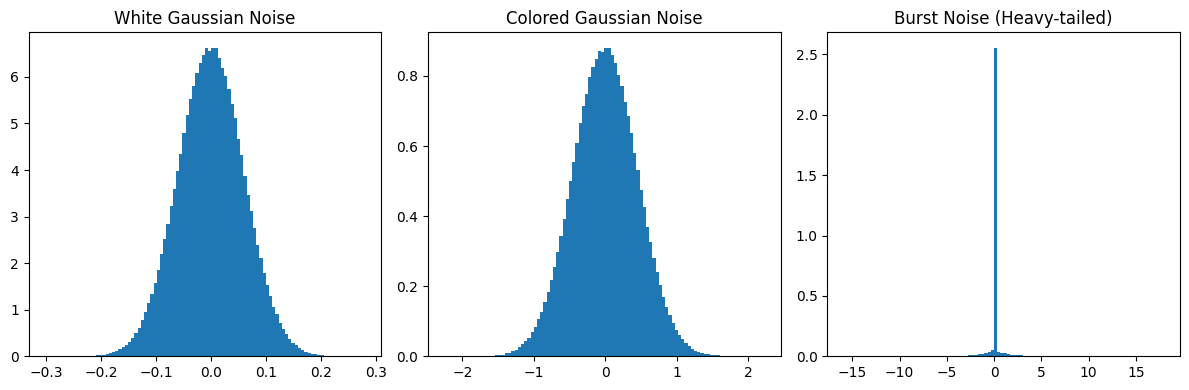

In [12]:
# ============================================================
# Noise distribution visualization
# ============================================================

def extract_noise(channel_fn, z):
    with torch.no_grad():
        z_noisy = channel_fn(z)
    return (z_noisy - z).cpu().numpy().flatten()

# create dummy latent vectors
num_samples = 20000
latent_dim = LATENT_DIM

z = torch.zeros((num_samples, latent_dim)).to(DEVICE)

# extract noise samples
white_noise = extract_noise(train_white_channel, z)
colored_noise = extract_noise(train_colored_channel, z)
burst_noise = extract_noise(train_burst_channel, z)

# plotting
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(white_noise, bins=100, density=True)
plt.title("White Gaussian Noise")

plt.subplot(1, 3, 2)
plt.hist(colored_noise, bins=100, density=True)
plt.title("Colored Gaussian Noise")

plt.subplot(1, 3, 3)
plt.hist(burst_noise, bins=100, density=True)
plt.title("Burst Noise (Heavy-tailed)")

plt.tight_layout()
plt.show()

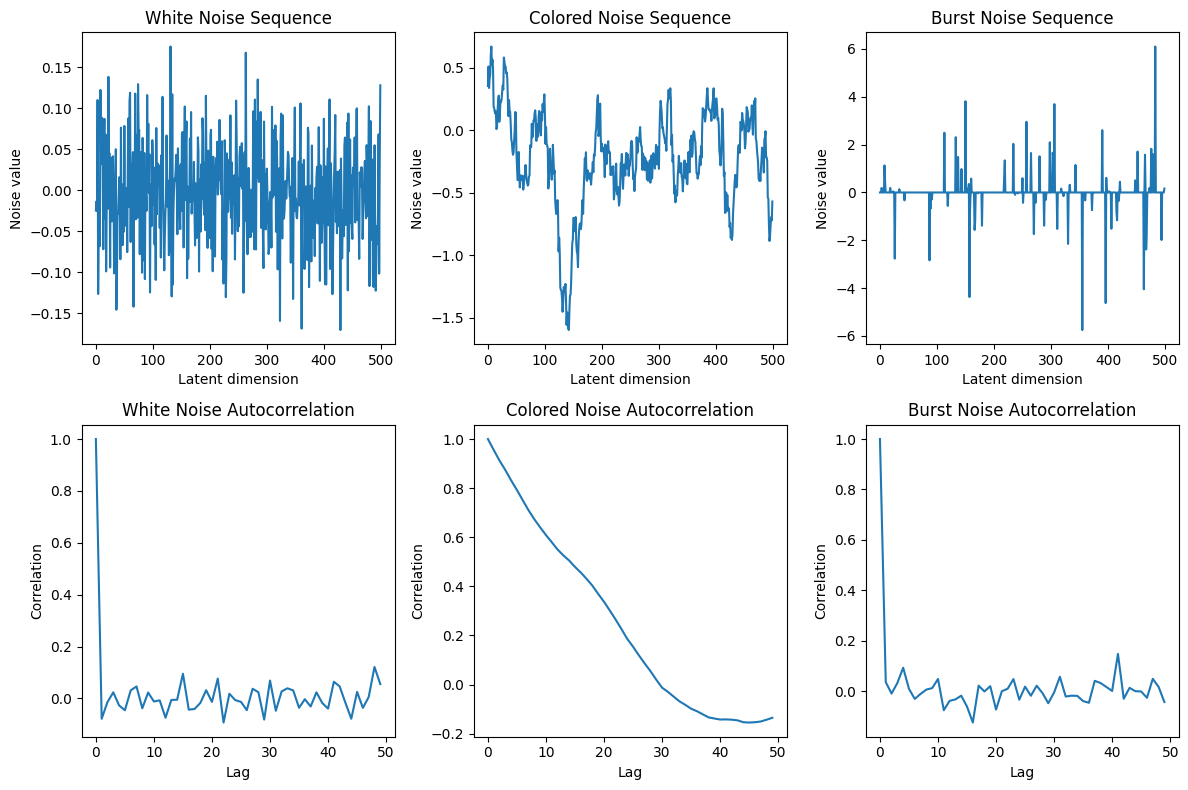

In [13]:
# ============================================================
# Correlation structure visualization (version-safe)
# ============================================================

def generate_noise_sequence(channel_fn, length=500):
    z = torch.zeros((1, length)).to(DEVICE)
    with torch.no_grad():
        z_noisy = channel_fn(z)
    return (z_noisy - z).cpu().numpy().flatten()

def autocorrelation(x, max_lag=50):
    x = x - np.mean(x)
    result = np.correlate(x, x, mode="full")
    result = result[result.size // 2:]
    result = result / result[0]
    return result[:max_lag]

length = 500
max_lag = 50

white_seq = generate_noise_sequence(train_white_channel, length)
colored_seq = generate_noise_sequence(train_colored_channel, length)
burst_seq = generate_noise_sequence(train_burst_channel, length)

acf_white = autocorrelation(white_seq, max_lag)
acf_colored = autocorrelation(colored_seq, max_lag)
acf_burst = autocorrelation(burst_seq, max_lag)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.plot(white_seq)
plt.title("White Noise Sequence")
plt.xlabel("Latent dimension")
plt.ylabel("Noise value")

plt.subplot(2, 3, 2)
plt.plot(colored_seq)
plt.title("Colored Noise Sequence")
plt.xlabel("Latent dimension")
plt.ylabel("Noise value")

plt.subplot(2, 3, 3)
plt.plot(burst_seq)
plt.title("Burst Noise Sequence")
plt.xlabel("Latent dimension")
plt.ylabel("Noise value")

plt.subplot(2, 3, 4)
plt.plot(acf_white)
plt.title("White Noise Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.subplot(2, 3, 5)
plt.plot(acf_colored)
plt.title("Colored Noise Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.subplot(2, 3, 6)
plt.plot(acf_burst)
plt.title("Burst Noise Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Correlation")

plt.tight_layout()
plt.show()

# Estimating Noise Distributions

Using device: cpu
Feature matrix: (12000, 22)
Family labels: (12000,)

Generated parameter summary:


true_variance                               true_alpha  \
                          mean       std       min       max       mean   
channel                                                                   
burst                 0.135870  0.065999  0.020150  0.249977        NaN   
colored_gaussian      0.135171  0.065789  0.020018  0.249943   0.586955   
white_gaussian        0.135316  0.066271  0.020022  0.249971   0.000000   

                                               burst_prob                     \
                       std       min       max       mean      std       min   
channel                                                                        
burst                  NaN       NaN       NaN   0.136009  0.06699  0.020044   
colored_gaussian  0.226271  0.200037  0.979513        NaN      NaN       NaN   
white_gaussian    0.000000  0.000000  0.000000        NaN      NaN       NaN   

                           burst_scale                                \
                       max        mean       std       min       max   
channel                                                                
burst             0.249962    0.783733  0.365671  0.211763  2.431228   
colored_gaussian       NaN         NaN       NaN       NaN       NaN   
white_gaussian         NaN         NaN       NaN       NaN       NaN   

                 sample_variance                                
                            mean       std       min       max  
channel                                                         
burst                   0.136196  0.085590  0.004111  0.790868  
colored_gaussian        0.133122  0.067167  0.012730  0.356737  
white_gaussian          0.135136  0.066928  0.017620  0.293543


Validation classification accuracy:
1.0

Validation classification report:
              precision    recall  f1-score   support

    gaussian       1.00      1.00      1.00      2000
       burst       1.00      1.00      1.00      1000

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000


Validation confusion matrix:
[[2000    0]
 [   0 1000]]

Fresh test classification accuracy:
1.0

Fresh test classification report:
              precision    recall  f1-score   support

    gaussian       1.00      1.00      1.00      4000
       burst       1.00      1.00      1.00      2000

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000


Fresh test confusion matrix:
[[4000    0]
 [   0 2000]]

Summary by true channel:


,true_channel,family_accuracy,mean_estimate_MAE,variance_estimate_MAE,variance_estimate_RMSE,alpha_estimate_MAE,covariance_relative_frobenius_error,avg_true_variance,avg_var_hat,avg_true_alpha,avg_alpha_hat
0,burst,1.0,0.011997,0.034726,0.055272,NaN,NaN,0.132904,0.132150,NaN,NaN
1,colored_gaussian,1.0,0.031435,0.011785,0.018540,0.026724,0.140891,0.133526,0.131262,0.588006,0.581261
2,white_gaussian,1.0,0.012656,0.006689,0.009369,0.034402,0.077459,0.134353,0.133651,0.000000,-0.002301



Summary by true family:


,true_family,family_accuracy,mean_estimate_MAE,variance_estimate_MAE,variance_estimate_RMSE
0,burst,1.0,0.011997,0.034726,0.055272
1,gaussian,1.0,0.022045,0.009237,0.014689



Overall metrics:
Family classification error: 0.0
Mean estimate MAE: 0.018695712
Variance estimate MAE: 0.017733186
Variance estimate RMSE: 0.034090612

Gaussian-only structure metrics:
Alpha estimate MAE: 0.03056253250805503
Covariance relative Frobenius error: 0.10917491844158916


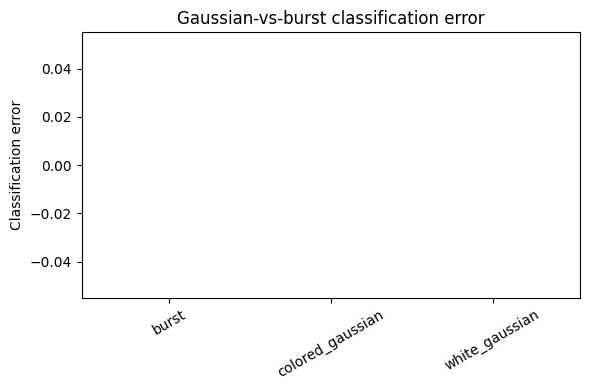

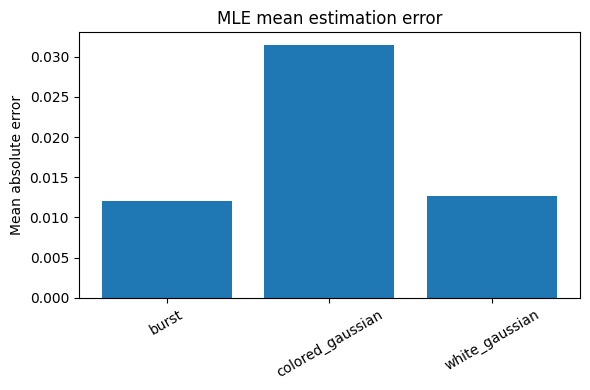

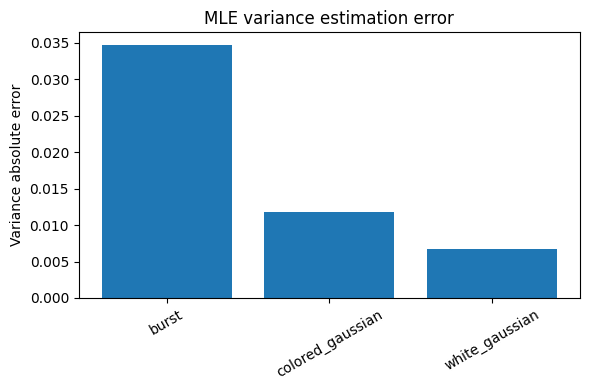

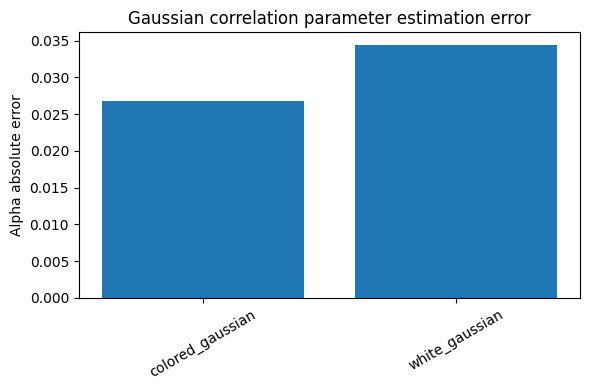

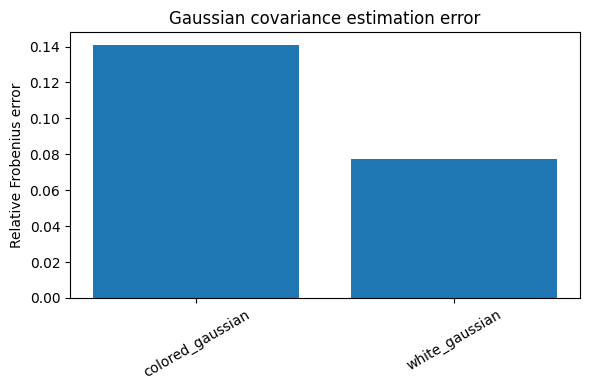

In [14]:
# ============================================================
# Gaussian-vs-burst noise classification
# Randomized parameters with matched variance ranges
# ============================================================

import math
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# ============================================================
# 0. Reproducibility
# ============================================================

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ============================================================
# 1. Global settings
# ============================================================

SEQUENCE_LENGTH = 512

N_TRAIN_PER_CHANNEL = 4000
N_TEST_PER_CHANNEL = 2000

# All channels are forced to have target marginal variance in this range.
# This removes variance/scale as an easy classification shortcut.
VAR_RANGE = (0.02, 0.25)

# Colored Gaussian AR(1) correlation range
ALPHA_RANGE = (0.20, 0.98)

# Burst sparsity range
BURST_PROB_RANGE = (0.02, 0.25)

CHANNEL_NAMES = [
    "white_gaussian",
    "colored_gaussian",
    "burst",
]

FAMILY_LABELS = {
    "white_gaussian": 0,
    "colored_gaussian": 0,
    "burst": 1,
}

FAMILY_NAMES = {
    0: "gaussian",
    1: "burst",
}

# ============================================================
# 2. Parameterized noise samplers
# ============================================================

def sample_uniform(low, high):
    return np.random.uniform(low, high)


def sample_white_gaussian(sequence_length):
    target_var = sample_uniform(*VAR_RANGE)
    sigma = math.sqrt(target_var)

    x = sigma * torch.randn(sequence_length, device=DEVICE)

    params = {
        "family": "gaussian",
        "channel": "white_gaussian",
        "true_mean": 0.0,
        "true_variance": target_var,
        "true_alpha": 0.0,
        "sigma": sigma,
        "burst_prob": np.nan,
        "burst_scale": np.nan,
    }

    return x.cpu().numpy(), params


def sample_colored_gaussian(sequence_length):
    target_var = sample_uniform(*VAR_RANGE)
    sigma = math.sqrt(target_var)
    alpha = sample_uniform(*ALPHA_RANGE)

    eps = sigma * torch.randn(sequence_length, device=DEVICE)
    x = torch.zeros(sequence_length, device=DEVICE)

    x[0] = eps[0]
    innovation_scale = math.sqrt(1 - alpha**2)

    for i in range(1, sequence_length):
        x[i] = alpha * x[i - 1] + innovation_scale * eps[i]

    params = {
        "family": "gaussian",
        "channel": "colored_gaussian",
        "true_mean": 0.0,
        "true_variance": target_var,
        "true_alpha": alpha,
        "sigma": sigma,
        "burst_prob": np.nan,
        "burst_scale": np.nan,
    }

    return x.cpu().numpy(), params


def sample_burst(sequence_length):
    target_var = sample_uniform(*VAR_RANGE)
    burst_prob = sample_uniform(*BURST_PROB_RANGE)

    # For Bernoulli(p) * Laplace(0, b):
    # Var = p * 2b^2
    burst_scale = math.sqrt(target_var / (2 * burst_prob))

    mask = (torch.rand(sequence_length, device=DEVICE) < burst_prob).float()

    laplace = torch.distributions.Laplace(
        torch.tensor(0.0, device=DEVICE),
        torch.tensor(burst_scale, device=DEVICE)
    )

    x = laplace.sample((sequence_length,)) * mask

    params = {
        "family": "burst",
        "channel": "burst",
        "true_mean": 0.0,
        "true_variance": target_var,
        "true_alpha": np.nan,
        "sigma": np.nan,
        "burst_prob": burst_prob,
        "burst_scale": burst_scale,
    }

    return x.cpu().numpy(), params


def sample_noise(channel_name, sequence_length):
    if channel_name == "white_gaussian":
        return sample_white_gaussian(sequence_length)
    elif channel_name == "colored_gaussian":
        return sample_colored_gaussian(sequence_length)
    elif channel_name == "burst":
        return sample_burst(sequence_length)
    else:
        raise ValueError(f"Unknown channel: {channel_name}")

# ============================================================
# 3. Feature extraction
# ============================================================

def autocorr_at_lag(x, lag):
    x = np.asarray(x)
    x = x - np.mean(x)

    if lag >= len(x):
        return 0.0

    denom = np.dot(x, x) + 1e-12
    return np.dot(x[:-lag], x[lag:]) / denom


def autocorr_features(x, lags=(1, 2, 4, 8, 16, 32)):
    return [autocorr_at_lag(x, lag) for lag in lags]


def extract_features(x):
    x = np.asarray(x)
    abs_x = np.abs(x)

    q = np.quantile(x, [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

    # Normalize scale-sensitive shape features by std so the classifier
    # cannot use raw variance as an easy shortcut.
    mu = np.mean(x)
    std = np.std(x) + 1e-12
    z = (x - mu) / std
    abs_z = np.abs(z)

    feats = [
        skew(z),
        kurtosis(z, fisher=True),

        np.mean(abs_z),
        np.max(abs_z),

        np.mean(abs_z > 1.0),
        np.mean(abs_z > 2.0),
        np.mean(abs_z > 3.0),
        np.mean(abs_z > 4.0),

        np.mean(np.isclose(x, 0.0, atol=1e-8)),

        q[0] / std,
        q[1] / std,
        q[2] / std,
        q[3] / std,
        q[4] / std,
        q[5] / std,
        q[6] / std,
    ]

    feats.extend(autocorr_features(z))

    return np.array(feats, dtype=np.float32)

# ============================================================
# 4. Dataset generation
# ============================================================

def build_dataset(n_per_channel):
    X = []
    y = []
    rows = []

    for channel_name in CHANNEL_NAMES:
        for _ in range(n_per_channel):
            seq, params = sample_noise(channel_name, SEQUENCE_LENGTH)

            X.append(extract_features(seq))
            y.append(FAMILY_LABELS[channel_name])

            params = dict(params)
            params["sample_mean"] = np.mean(seq)
            params["sample_variance"] = np.var(seq, ddof=0)
            rows.append(params)

    X = np.vstack(X)
    y = np.array(y)
    meta = pd.DataFrame(rows)

    return X, y, meta


X, y, meta = build_dataset(N_TRAIN_PER_CHANNEL)

print("Feature matrix:", X.shape)
print("Family labels:", y.shape)

print("\nGenerated parameter summary:")
display(meta.groupby("channel")[[
    "true_variance",
    "true_alpha",
    "burst_prob",
    "burst_scale",
    "sample_variance",
]].agg(["mean", "std", "min", "max"]))

# ============================================================
# 5. Train/validation split
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y,
)

# ============================================================
# 6. Family classifier
# ============================================================

clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1,
)

clf.fit(X_train, y_train)

y_val_pred = clf.predict(X_val)

print("\nValidation classification accuracy:")
print(accuracy_score(y_val, y_val_pred))

print("\nValidation classification report:")
print(classification_report(
    y_val,
    y_val_pred,
    target_names=["gaussian", "burst"]
))

print("\nValidation confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))

# ============================================================
# 7. Estimators
# ============================================================

def mle_mean_variance(x):
    mu_hat = np.mean(x)
    var_hat = np.mean((x - mu_hat) ** 2)
    return mu_hat, var_hat


def estimate_alpha_lag1(x):
    return autocorr_at_lag(x, lag=1)


def estimate_ar1_covariance(var_hat, alpha_hat, dim):
    idx = np.arange(dim)
    distance = np.abs(idx[:, None] - idx[None, :])
    return var_hat * (alpha_hat ** distance)


def true_ar1_covariance(variance, alpha, dim):
    idx = np.arange(dim)
    distance = np.abs(idx[:, None] - idx[None, :])
    return variance * (alpha ** distance)


def covariance_relative_frobenius_error(cov_hat, cov_true):
    return (
        np.linalg.norm(cov_hat - cov_true, ord="fro")
        / (np.linalg.norm(cov_true, ord="fro") + 1e-12)
    )

# ============================================================
# 8. Fresh test set evaluation
# ============================================================

X_test, y_test, test_meta = build_dataset(N_TEST_PER_CHANNEL)

y_test_pred = clf.predict(X_test)

print("\nFresh test classification accuracy:")
print(accuracy_score(y_test, y_test_pred))

print("\nFresh test classification report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["gaussian", "burst"]
))

print("\nFresh test confusion matrix:")
print(confusion_matrix(y_test, y_test_pred))

# ============================================================
# 9. Parameter-estimation evaluation
# ============================================================

records = []

for i in range(len(test_meta)):
    channel = test_meta.loc[i, "channel"]
    true_family = test_meta.loc[i, "family"]
    true_var = test_meta.loc[i, "true_variance"]
    true_alpha = test_meta.loc[i, "true_alpha"]

    # Reconstruct one sequence for evaluation.
    # This is independent from the feature matrix values.
    seq, params = sample_noise(channel, SEQUENCE_LENGTH)

    pred_family_id = clf.predict(extract_features(seq).reshape(1, -1))[0]
    pred_family = FAMILY_NAMES[pred_family_id]

    mu_hat, var_hat = mle_mean_variance(seq)

    mean_abs_error = abs(mu_hat - params["true_mean"])
    variance_abs_error = abs(var_hat - params["true_variance"])
    variance_squared_error = (var_hat - params["true_variance"]) ** 2

    alpha_hat = np.nan
    alpha_abs_error = np.nan
    cov_rel_frob_error = np.nan

    if params["family"] == "gaussian":
        alpha_hat = estimate_alpha_lag1(seq)
        alpha_abs_error = abs(alpha_hat - params["true_alpha"])

        cov_hat = estimate_ar1_covariance(
            var_hat=var_hat,
            alpha_hat=alpha_hat,
            dim=SEQUENCE_LENGTH
        )

        cov_true = true_ar1_covariance(
            variance=params["true_variance"],
            alpha=params["true_alpha"],
            dim=SEQUENCE_LENGTH
        )

        cov_rel_frob_error = covariance_relative_frobenius_error(cov_hat, cov_true)

    records.append({
        "true_channel": channel,
        "true_family": params["family"],
        "pred_family": pred_family,
        "family_correct": int(pred_family == params["family"]),

        "true_variance": params["true_variance"],
        "mu_hat": mu_hat,
        "var_hat": var_hat,

        "true_alpha": params["true_alpha"],
        "alpha_hat": alpha_hat,

        "mean_abs_error": mean_abs_error,
        "variance_abs_error": variance_abs_error,
        "variance_squared_error": variance_squared_error,

        "alpha_abs_error": alpha_abs_error,
        "covariance_relative_frobenius_error": cov_rel_frob_error,

        "burst_prob": params["burst_prob"],
        "burst_scale": params["burst_scale"],
    })

df = pd.DataFrame(records)

# ============================================================
# 10. Summaries
# ============================================================

summary_by_channel = df.groupby("true_channel").agg(
    family_accuracy=("family_correct", "mean"),
    mean_estimate_MAE=("mean_abs_error", "mean"),
    variance_estimate_MAE=("variance_abs_error", "mean"),
    variance_estimate_RMSE=("variance_squared_error", lambda x: np.sqrt(np.mean(x))),
    alpha_estimate_MAE=("alpha_abs_error", "mean"),
    covariance_relative_frobenius_error=("covariance_relative_frobenius_error", "mean"),
    avg_true_variance=("true_variance", "mean"),
    avg_var_hat=("var_hat", "mean"),
    avg_true_alpha=("true_alpha", "mean"),
    avg_alpha_hat=("alpha_hat", "mean"),
).reset_index()

summary_by_family = df.groupby("true_family").agg(
    family_accuracy=("family_correct", "mean"),
    mean_estimate_MAE=("mean_abs_error", "mean"),
    variance_estimate_MAE=("variance_abs_error", "mean"),
    variance_estimate_RMSE=("variance_squared_error", lambda x: np.sqrt(np.mean(x))),
).reset_index()

print("\nSummary by true channel:")
display(summary_by_channel)

print("\nSummary by true family:")
display(summary_by_family)

print("\nOverall metrics:")
print("Family classification error:", 1.0 - df["family_correct"].mean())
print("Mean estimate MAE:", df["mean_abs_error"].mean())
print("Variance estimate MAE:", df["variance_abs_error"].mean())
print("Variance estimate RMSE:", np.sqrt(df["variance_squared_error"].mean()))

gaussian_df = df[df["true_family"] == "gaussian"]

print("\nGaussian-only structure metrics:")
print("Alpha estimate MAE:", gaussian_df["alpha_abs_error"].mean())
print(
    "Covariance relative Frobenius error:",
    gaussian_df["covariance_relative_frobenius_error"].mean()
)

# ============================================================
# 11. Visualizations
# ============================================================

plt.figure(figsize=(6, 4))
plt.bar(summary_by_channel["true_channel"], 1.0 - summary_by_channel["family_accuracy"])
plt.ylabel("Classification error")
plt.title("Gaussian-vs-burst classification error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(summary_by_channel["true_channel"], summary_by_channel["mean_estimate_MAE"])
plt.ylabel("Mean absolute error")
plt.title("MLE mean estimation error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(summary_by_channel["true_channel"], summary_by_channel["variance_estimate_MAE"])
plt.ylabel("Variance absolute error")
plt.title("MLE variance estimation error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

gaussian_summary = summary_by_channel[
    summary_by_channel["true_channel"].isin(["white_gaussian", "colored_gaussian"])
]

plt.figure(figsize=(6, 4))
plt.bar(gaussian_summary["true_channel"], gaussian_summary["alpha_estimate_MAE"])
plt.ylabel("Alpha absolute error")
plt.title("Gaussian correlation parameter estimation error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(
    gaussian_summary["true_channel"],
    gaussian_summary["covariance_relative_frobenius_error"]
)
plt.ylabel("Relative Frobenius error")
plt.title("Gaussian covariance estimation error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Feature matrix: (18000, 23)
Labels: (18000,)

Classification accuracy:
0.9926666666666667

Classification report:
               precision    recall  f1-score   support

         hiss       1.00      1.00      1.00       750
        pulse       1.00      1.00      1.00       750
stepped_tones       1.00      0.96      0.98       750
      warbler       0.96      1.00      0.98       750
recorded_like       1.00      1.00      1.00       750
        spark       1.00      1.00      1.00       750

     accuracy                           0.99      4500
    macro avg       0.99      0.99      0.99      4500
 weighted avg       0.99      0.99      0.99      4500


Confusion matrix:
[[750   0   0   0   0   0]
 [  0 749   0   0   0   1]
 [  0   0 718  32   0   0]
 [  0   0   0 750   0   0]
 [  0   0   0   0 750   0]
 [  0   0   0   0   0 750]]

Basic parameter summary:


,true_family,family_accuracy,mean_MAE,variance_MAE,rms_MAE
0,hiss,1.000,0.005282,0.000049,2.997737e-13
1,pulse,1.000,0.000000,0.000000,4.441480e-04
2,recorded_like,1.000,0.000000,0.000000,5.563901e-13
3,spark,1.000,0.000000,0.000000,3.000246e-13
4,stepped_tones,0.974,0.000000,0.000000,7.366965e-04
5,warbler,1.000,0.000000,0.000000,7.866005e-04



Overall:
Family classification error: 0.0043333333333333
Mean MAE: 0.0008802871744362836
Variance MAE: 8.176467249196429e-06
RMS MAE: 0.00032790749974024024

Family-specific parameter errors:

hiss
  pulse-rate MAE: nan
  dominant-frequency MAE: nan
  modulation-frequency MAE: nan
  step-rate MAE: nan

pulse
  pulse-rate MAE: 28.19727973302199
  dominant-frequency MAE: nan
  modulation-frequency MAE: nan
  step-rate MAE: nan

stepped_tones
  pulse-rate MAE: nan
  dominant-frequency MAE: 448.61692840242455
  modulation-frequency MAE: nan
  step-rate MAE: 5.848049281314168

warbler
  pulse-rate MAE: nan
  dominant-frequency MAE: 176.10199157520464
  modulation-frequency MAE: 5.908447577800343
  step-rate MAE: nan

recorded_like
  pulse-rate MAE: nan
  dominant-frequency MAE: nan
  modulation-frequency MAE: 11.138787234162514
  step-rate MAE: nan

spark
  pulse-rate MAE: 24.7628839325545
  dominant-frequency MAE: nan
  modulation-frequency MAE: nan
  step-rate MAE: nan


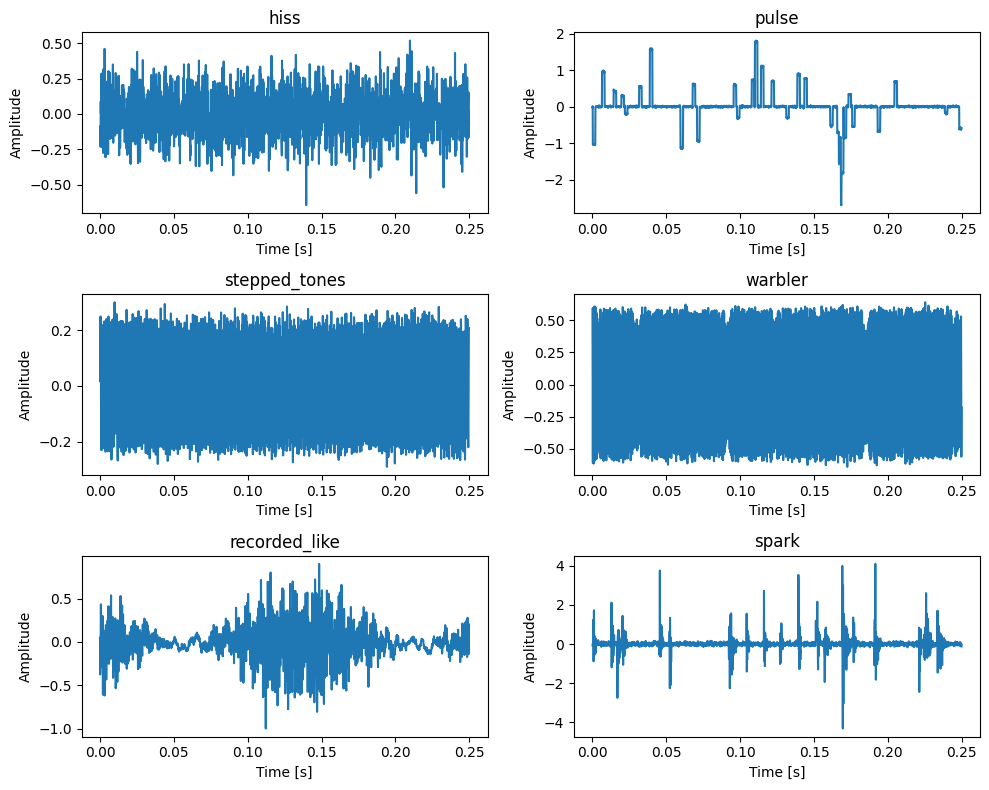

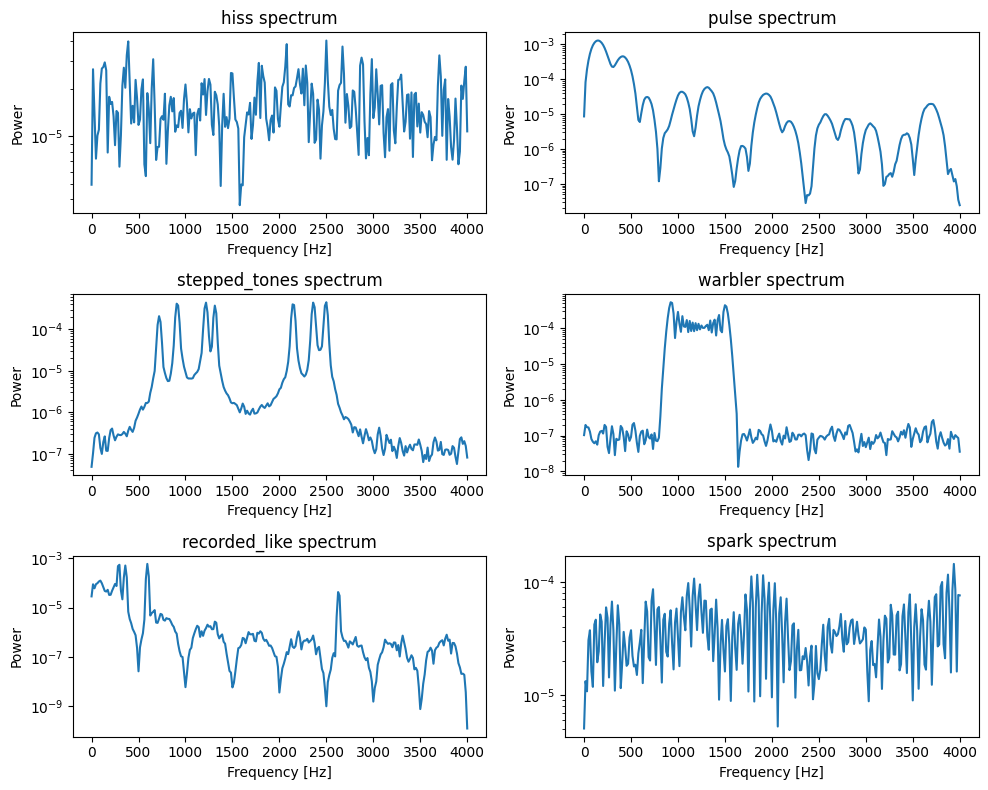

In [15]:
# ============================================================
# Synthetic interference family classification
# + family-specific parameter estimation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import welch, find_peaks
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# ============================================================
# 0. Settings
# ============================================================

SEED = 1
rng = np.random.default_rng(SEED)

FS = 8000
DURATION = 0.25
N = int(FS * DURATION)

N_PER_FAMILY = 3000
TEST_SIZE = 0.25

FAMILIES = [
    "hiss",
    "pulse",
    "stepped_tones",
    "warbler",
    "recorded_like",
    "spark",
]

# ============================================================
# 1. Utilities
# ============================================================

def normalize_to_rms(x, target_rms):
    rms = np.sqrt(np.mean(x**2)) + 1e-12
    return x * (target_rms / rms)


def add_background(x, bg_std=0.02):
    return x + rng.normal(0, bg_std, size=len(x))


def random_rms():
    return rng.uniform(0.15, 0.45)


def power_spectrum(x):
    f, pxx = welch(x, fs=FS, nperseg=min(512, len(x)))
    return f, pxx + 1e-12


# ============================================================
# 2. Synthetic families
# ============================================================

def make_hiss():
    target_rms = random_rms()
    x = rng.normal(0, 1, size=N)
    x = normalize_to_rms(x, target_rms)

    params = {
        "family": "hiss",
        "true_rms": target_rms,
        "true_mean": 0.0,
        "true_variance": target_rms**2,
        "pulse_rate": np.nan,
        "dominant_freq": np.nan,
        "mod_freq": np.nan,
        "step_rate": np.nan,
    }
    return x, params


def make_pulse():
    target_rms = random_rms()
    pulse_rate = rng.uniform(20, 120)
    pulse_width = rng.integers(2, 20)

    x = np.zeros(N)
    expected_pulses = int(pulse_rate * DURATION)
    n_pulses = max(1, rng.poisson(expected_pulses))

    centers = rng.integers(0, N, size=n_pulses)
    for c in centers:
        lo = max(0, c - pulse_width // 2)
        hi = min(N, c + pulse_width // 2)
        amp = rng.normal(0, 1)
        x[lo:hi] += amp

    x = normalize_to_rms(x, target_rms)
    x = add_background(x, bg_std=0.015)

    params = {
        "family": "pulse",
        "true_rms": target_rms,
        "true_mean": np.mean(x),
        "true_variance": np.var(x),
        "pulse_rate": pulse_rate,
        "dominant_freq": np.nan,
        "mod_freq": np.nan,
        "step_rate": np.nan,
    }
    return x, params


def make_stepped_tones():
    target_rms = random_rms()
    n_steps = rng.integers(3, 9)
    freqs = rng.uniform(300, 2500, size=n_steps)

    samples_per_step = N // n_steps
    x = np.zeros(N)
    phase = 0.0

    for i in range(n_steps):
        start = i * samples_per_step
        end = N if i == n_steps - 1 else (i + 1) * samples_per_step
        t = np.arange(end - start) / FS
        f = freqs[i]
        x[start:end] = np.sin(2 * np.pi * f * t + phase)
        phase += 2 * np.pi * f * len(t) / FS

    x = normalize_to_rms(x, target_rms)
    x = add_background(x, bg_std=0.02)

    params = {
        "family": "stepped_tones",
        "true_rms": target_rms,
        "true_mean": np.mean(x),
        "true_variance": np.var(x),
        "pulse_rate": np.nan,
        "dominant_freq": np.mean(freqs),
        "mod_freq": np.nan,
        "step_rate": n_steps / DURATION,
    }
    return x, params


def make_warbler():
    target_rms = random_rms()
    carrier = rng.uniform(400, 2200)
    mod_freq = rng.uniform(2, 20)
    freq_dev = rng.uniform(50, 350)

    t = np.arange(N) / FS
    inst_freq = carrier + freq_dev * np.sin(2 * np.pi * mod_freq * t)
    phase = 2 * np.pi * np.cumsum(inst_freq) / FS

    x = np.sin(phase)
    x = normalize_to_rms(x, target_rms)
    x = add_background(x, bg_std=0.02)

    params = {
        "family": "warbler",
        "true_rms": target_rms,
        "true_mean": np.mean(x),
        "true_variance": np.var(x),
        "pulse_rate": np.nan,
        "dominant_freq": carrier,
        "mod_freq": mod_freq,
        "step_rate": np.nan,
    }
    return x, params


def make_recorded_like():
    target_rms = random_rms()

    # synthetic "recorded-like" mixture:
    # several tones + slow amplitude envelope + colored noise
    t = np.arange(N) / FS

    n_components = rng.integers(3, 8)
    x = np.zeros(N)

    for _ in range(n_components):
        f = rng.uniform(100, 3000)
        phase = rng.uniform(0, 2 * np.pi)
        amp = rng.uniform(0.2, 1.0)
        x += amp * np.sin(2 * np.pi * f * t + phase)

    envelope_freq = rng.uniform(1, 8)
    envelope = 0.5 + 0.5 * np.sin(2 * np.pi * envelope_freq * t + rng.uniform(0, 2*np.pi))
    x = envelope * x

    # add colored-ish texture
    noise = rng.normal(0, 1, size=N)
    colored = np.convolve(noise, np.ones(16) / 16, mode="same")
    x += 0.6 * colored

    x = normalize_to_rms(x, target_rms)

    params = {
        "family": "recorded_like",
        "true_rms": target_rms,
        "true_mean": np.mean(x),
        "true_variance": np.var(x),
        "pulse_rate": np.nan,
        "dominant_freq": np.nan,
        "mod_freq": envelope_freq,
        "step_rate": np.nan,
    }
    return x, params


def make_spark():
    target_rms = random_rms()
    spark_rate = rng.uniform(30, 180)

    x = rng.normal(0, 0.15, size=N)

    expected_sparks = int(spark_rate * DURATION)
    n_sparks = max(1, rng.poisson(expected_sparks))

    for _ in range(n_sparks):
        c = rng.integers(0, N)
        decay_len = rng.integers(10, 60)
        amp = rng.choice([-1, 1]) * rng.uniform(2, 6)

        end = min(N, c + decay_len)
        k = np.arange(end - c)
        burst = amp * np.exp(-k / rng.uniform(4, 15)) * rng.normal(0, 1, size=len(k))
        x[c:end] += burst

    x = normalize_to_rms(x, target_rms)

    params = {
        "family": "spark",
        "true_rms": target_rms,
        "true_mean": np.mean(x),
        "true_variance": np.var(x),
        "pulse_rate": spark_rate,
        "dominant_freq": np.nan,
        "mod_freq": np.nan,
        "step_rate": np.nan,
    }
    return x, params


GENERATORS = {
    "hiss": make_hiss,
    "pulse": make_pulse,
    "stepped_tones": make_stepped_tones,
    "warbler": make_warbler,
    "recorded_like": make_recorded_like,
    "spark": make_spark,
}

# ============================================================
# 3. Feature extraction
# ============================================================

def zero_crossing_rate(x):
    return np.mean(x[:-1] * x[1:] < 0)


def spectral_features(x):
    f, pxx = power_spectrum(x)
    p = pxx / np.sum(pxx)

    centroid = np.sum(f * p)
    bandwidth = np.sqrt(np.sum(((f - centroid) ** 2) * p))
    flatness = np.exp(np.mean(np.log(pxx))) / np.mean(pxx)

    peak_idx = np.argmax(pxx)
    dom_freq = f[peak_idx]

    peaks, _ = find_peaks(pxx, distance=3)
    n_peaks = len(peaks)

    top_power_ratio = np.max(pxx) / np.sum(pxx)

    return [
        centroid,
        bandwidth,
        flatness,
        dom_freq,
        n_peaks,
        top_power_ratio,
    ]


def autocorr_at_lag(x, lag):
    x = x - np.mean(x)
    denom = np.dot(x, x) + 1e-12
    if lag >= len(x):
        return 0.0
    return np.dot(x[:-lag], x[lag:]) / denom


def extract_features(x):
    x = np.asarray(x)
    mu = np.mean(x)
    std = np.std(x) + 1e-12
    z = (x - mu) / std
    abs_z = np.abs(z)

    feats = [
        skew(z),
        kurtosis(z, fisher=True),
        np.mean(abs_z),
        np.max(abs_z),
        np.mean(abs_z > 1),
        np.mean(abs_z > 2),
        np.mean(abs_z > 3),
        np.mean(abs_z > 4),
        zero_crossing_rate(z),
    ]

    feats.extend(spectral_features(z))

    for lag in [1, 2, 4, 8, 16, 32, 64, 128]:
        feats.append(autocorr_at_lag(z, lag))

    return np.array(feats, dtype=np.float32)

# ============================================================
# 4. Dataset
# ============================================================

def build_dataset(n_per_family):
    X = []
    y = []
    rows = []

    for label, family in enumerate(FAMILIES):
        for _ in range(n_per_family):
            x, params = GENERATORS[family]()
            X.append(extract_features(x))
            y.append(label)

            row = dict(params)
            row["label"] = label
            row["sample_mean"] = np.mean(x)
            row["sample_variance"] = np.var(x)
            row["sample_rms"] = np.sqrt(np.mean(x**2))
            rows.append(row)

    return np.vstack(X), np.array(y), pd.DataFrame(rows)


X, y, meta = build_dataset(N_PER_FAMILY)

print("Feature matrix:", X.shape)
print("Labels:", y.shape)

# ============================================================
# 5. Train/test split
# ============================================================

X_train, X_test, y_train, y_test, meta_train, meta_test = train_test_split(
    X,
    y,
    meta,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

# ============================================================
# 6. Classifier
# ============================================================

clf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1,
)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("\nClassification accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=FAMILIES,
))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

# ============================================================
# 7. Parameter estimation
# ============================================================

def estimate_basic_params(x):
    return {
        "mean_hat": np.mean(x),
        "variance_hat": np.var(x, ddof=0),
        "rms_hat": np.sqrt(np.mean(x**2)),
    }


def estimate_dominant_frequency(x):
    f, pxx = power_spectrum(x)
    return f[np.argmax(pxx)]


def estimate_pulse_rate(x):
    z = (x - np.mean(x)) / (np.std(x) + 1e-12)
    peaks, _ = find_peaks(np.abs(z), height=3.0, distance=5)
    return len(peaks) / DURATION


def estimate_modulation_frequency(x):
    # crude envelope-based estimate
    envelope = np.abs(x)
    envelope = envelope - np.mean(envelope)

    f, pxx = welch(envelope, fs=FS, nperseg=min(512, len(envelope)))
    mask = (f >= 1) & (f <= 30)

    if np.sum(mask) == 0:
        return np.nan

    return f[mask][np.argmax(pxx[mask])]


def estimate_step_rate(x):
    # crude estimate based on dominant-frequency changes over short windows
    win = 256
    hop = 128

    doms = []

    for start in range(0, len(x) - win + 1, hop):
        segment = x[start:start + win]
        doms.append(estimate_dominant_frequency(segment))

    doms = np.array(doms)

    if len(doms) < 2:
        return np.nan

    changes = np.abs(np.diff(doms)) > 100
    return np.sum(changes) / DURATION


def estimate_family_params(x, pred_family):
    out = estimate_basic_params(x)

    out["dominant_freq_hat"] = np.nan
    out["pulse_rate_hat"] = np.nan
    out["mod_freq_hat"] = np.nan
    out["step_rate_hat"] = np.nan

    if pred_family in ["stepped_tones", "warbler"]:
        out["dominant_freq_hat"] = estimate_dominant_frequency(x)

    if pred_family in ["pulse", "spark"]:
        out["pulse_rate_hat"] = estimate_pulse_rate(x)

    if pred_family in ["warbler", "recorded_like"]:
        out["mod_freq_hat"] = estimate_modulation_frequency(x)

    if pred_family == "stepped_tones":
        out["step_rate_hat"] = estimate_step_rate(x)

    return out

# ============================================================
# 8. Fresh evaluation set for parameter errors
# ============================================================

N_EVAL_PER_FAMILY = 500

records = []

for true_label, family in enumerate(FAMILIES):
    for _ in range(N_EVAL_PER_FAMILY):
        x, true_params = GENERATORS[family]()

        features = extract_features(x).reshape(1, -1)
        pred_label = clf.predict(features)[0]
        pred_family = FAMILIES[pred_label]

        estimates = estimate_family_params(x, pred_family)

        record = {
            "true_family": family,
            "pred_family": pred_family,
            "family_correct": int(family == pred_family),

            "true_mean": true_params["true_mean"],
            "true_variance": true_params["true_variance"],
            "true_rms": true_params["true_rms"],

            "mean_hat": estimates["mean_hat"],
            "variance_hat": estimates["variance_hat"],
            "rms_hat": estimates["rms_hat"],

            "mean_abs_error": abs(estimates["mean_hat"] - true_params["true_mean"]),
            "variance_abs_error": abs(estimates["variance_hat"] - true_params["true_variance"]),
            "rms_abs_error": abs(estimates["rms_hat"] - true_params["true_rms"]),

            "true_pulse_rate": true_params["pulse_rate"],
            "pulse_rate_hat": estimates["pulse_rate_hat"],

            "true_dominant_freq": true_params["dominant_freq"],
            "dominant_freq_hat": estimates["dominant_freq_hat"],

            "true_mod_freq": true_params["mod_freq"],
            "mod_freq_hat": estimates["mod_freq_hat"],

            "true_step_rate": true_params["step_rate"],
            "step_rate_hat": estimates["step_rate_hat"],
        }

        records.append(record)

df = pd.DataFrame(records)

# ============================================================
# 9. Summaries
# ============================================================

summary = df.groupby("true_family").agg(
    family_accuracy=("family_correct", "mean"),
    mean_MAE=("mean_abs_error", "mean"),
    variance_MAE=("variance_abs_error", "mean"),
    rms_MAE=("rms_abs_error", "mean"),
).reset_index()

print("\nBasic parameter summary:")
display(summary)

print("\nOverall:")
print("Family classification error:", 1 - df["family_correct"].mean())
print("Mean MAE:", df["mean_abs_error"].mean())
print("Variance MAE:", df["variance_abs_error"].mean())
print("RMS MAE:", df["rms_abs_error"].mean())

# Family-specific parameter errors

def mae_ignore_nan(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)
    if np.sum(mask) == 0:
        return np.nan
    return np.mean(np.abs(a[mask] - b[mask]))

print("\nFamily-specific parameter errors:")

for family in FAMILIES:
    sub = df[df["true_family"] == family]

    pulse_mae = mae_ignore_nan(
        sub["true_pulse_rate"].to_numpy(),
        sub["pulse_rate_hat"].to_numpy()
    )

    dom_mae = mae_ignore_nan(
        sub["true_dominant_freq"].to_numpy(),
        sub["dominant_freq_hat"].to_numpy()
    )

    mod_mae = mae_ignore_nan(
        sub["true_mod_freq"].to_numpy(),
        sub["mod_freq_hat"].to_numpy()
    )

    step_mae = mae_ignore_nan(
        sub["true_step_rate"].to_numpy(),
        sub["step_rate_hat"].to_numpy()
    )

    print(f"\n{family}")
    print("  pulse-rate MAE:", pulse_mae)
    print("  dominant-frequency MAE:", dom_mae)
    print("  modulation-frequency MAE:", mod_mae)
    print("  step-rate MAE:", step_mae)

# ============================================================
# 10. Example visualizations
# ============================================================

plt.figure(figsize=(10, 8))

for i, family in enumerate(FAMILIES):
    x, _ = GENERATORS[family]()
    t = np.arange(N) / FS

    plt.subplot(3, 2, i + 1)
    plt.plot(t, x)
    plt.title(family)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))

for i, family in enumerate(FAMILIES):
    x, _ = GENERATORS[family]()
    f, pxx = power_spectrum(x)

    plt.subplot(3, 2, i + 1)
    plt.semilogy(f, pxx)
    plt.title(f"{family} spectrum")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Power")

plt.tight_layout()
plt.show()

Using device: cpu
LibriSpeech audio already present under /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech
Found dev-clean files: 2703
Found test-clean files: 2620

Building latent-noise classifier dataset...

Latent-noise classification accuracy:
0.9135555555555556

Latent-noise classification report:
              precision    recall  f1-score   support

        hiss       1.00      1.00      1.00       750
       pulse       0.77      0.70      0.73       750
     stepped       1.00      0.99      1.00       750
     warbler       0.99      1.00      1.00       750
    recorded       1.00      1.00      1.00       750
       spark       0.73      0.79      0.76       750

    accuracy                           0.91      4500
   macro avg       0.91      0.91      0.91      4500
weighted avg       0.91      0.91      0.91      4500


Latent-noise confusion matrix:
[[749   0   0   0   1   0]
 [  0 527   0   0   0 223]
 [  0   0 745   5   0   0]
 [  0   0   1 7

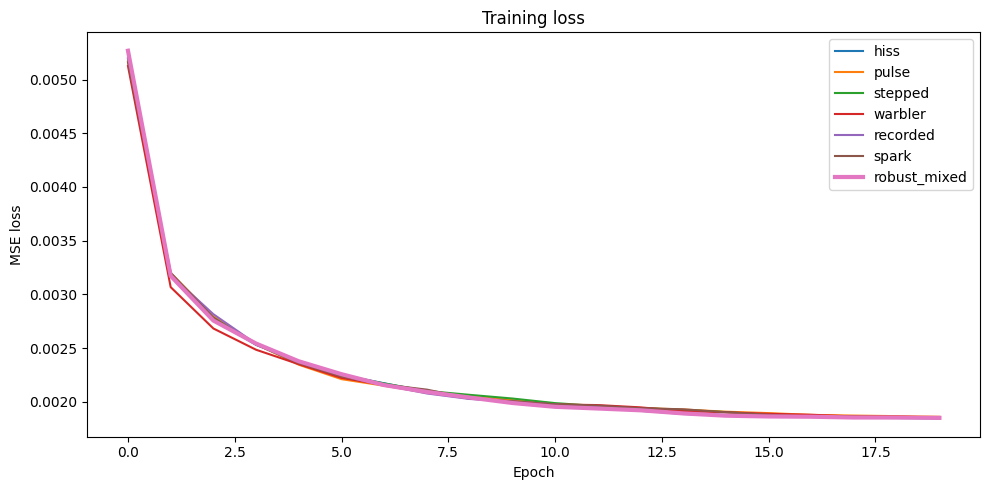


Demo file: /Users/aaryakhanna/Documents/GitHub/autoencoder_denoiser/data/librispeech/LibriSpeech/test-clean/1188/133604/1188-133604-0009.flac
Demo length: 21.0 sec


In [ ]:
# ============================================================
# Structured channel-noise autoencoder experiment
# Families:
#   hiss, pulse, stepped tones, warbler, recorded-like, spark
# ============================================================

import os
import math
import random
import tarfile
import urllib.request
from pathlib import Path

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

from IPython.display import Audio, display

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from scipy.stats import skew, kurtosis
from scipy.signal import welch, find_peaks

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split


# ============================================================
# 0. Reproducibility
# ============================================================

SEED = 1
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


# ============================================================
# 1. Paths and basic settings
# ============================================================

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    DATA_ROOT = Path("/content")
else:
    DATA_ROOT = Path.cwd() / "data" / "librispeech"
DATA_ROOT.mkdir(parents=True, exist_ok=True)

LIBRISPEECH_ARCHIVES = {
    "dev-clean.tar.gz": "https://www.openslr.org/resources/12/dev-clean.tar.gz",
    "test-clean.tar.gz": "https://www.openslr.org/resources/12/test-clean.tar.gz",
}


def _is_valid_gzip(path: Path) -> bool:
    try:
        with path.open("rb") as f:
            return f.read(2) == b"\x1f\x8b"
    except OSError:
        return False


def _download(url: str, dest: Path) -> None:
    print(f"Downloading {dest.name} from OpenSLR (may take several minutes)...")
    dest.parent.mkdir(parents=True, exist_ok=True)
    tmp = dest.with_suffix(dest.suffix + ".part")
    urllib.request.urlretrieve(url, tmp)
    tmp.replace(dest)


def ensure_librispeech() -> None:
    existing = sorted(DATA_ROOT.rglob("*.flac"))
    if any("dev-clean" in str(p) for p in existing) and any(
        "test-clean" in str(p) for p in existing
    ):
        print("LibriSpeech audio already present under", DATA_ROOT)
        return

    for name, url in LIBRISPEECH_ARCHIVES.items():
        dest = DATA_ROOT / name
        if dest.exists() and not _is_valid_gzip(dest):
            print("Removing invalid archive:", dest)
            dest.unlink(missing_ok=True)
        if not dest.exists():
            _download(url, dest)
        if not _is_valid_gzip(dest):
            raise RuntimeError(
                f"{dest} is not a valid gzip file. Remove it and retry with a stable network."
            )

    for name in LIBRISPEECH_ARCHIVES:
        dest = DATA_ROOT / name
        print("Extracting", dest)
        try:
            with tarfile.open(dest, "r:gz") as tar:
                tar.extractall(path=str(DATA_ROOT))
        except (tarfile.ReadError, OSError, EOFError) as e:
            dest.unlink(missing_ok=True)
            raise RuntimeError(
                f"Failed to extract {dest}: {e!r}. Removed corrupt file; re-run to re-download."
            ) from e


ensure_librispeech()

all_flac = sorted(DATA_ROOT.rglob("*.flac"))

dev_clean_files = [p for p in all_flac if "dev-clean" in str(p)]
test_clean_files = [p for p in all_flac if "test-clean" in str(p)]

print("Found dev-clean files:", len(dev_clean_files))
print("Found test-clean files:", len(test_clean_files))

if len(dev_clean_files) == 0 or len(test_clean_files) == 0:
    raise ValueError("No LibriSpeech .flac files found after extraction.")

TARGET_SR = 16000

FRAME_SIZE = 512
HOP_SIZE = 512

MAX_TRAIN_FILES = 1200
MAX_TEST_FILES = 300

LATENT_DIM = 64
BATCH_SIZE = 256
EPOCHS = 20
LEARNING_RATE = 1e-3

DEMO_SECONDS = 21

CHANNEL_NAMES = [
    "hiss",
    "pulse",
    "stepped",
    "warbler",
    "recorded",
    "spark",
]

CHANNEL_BITS = {
    "hiss": "000",
    "pulse": "001",
    "stepped": "010",
    "warbler": "011",
    "recorded": "100",
    "spark": "101",
}


# ============================================================
# 2. Audio utilities
# ============================================================

def normalize_audio(x: np.ndarray) -> np.ndarray:
    peak = np.max(np.abs(x))
    if peak < 1e-8:
        return x.astype(np.float32)
    return (x / peak).astype(np.float32)


def load_wav(path: Path, target_sr: int = 16000) -> np.ndarray:
    audio, sr = sf.read(str(path))

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if sr != target_sr:
        raise ValueError(f"{path} has sample rate {sr}, expected {target_sr}")

    return normalize_audio(audio)


def pick_training_subset(files, max_files=80, min_seconds=3.0):
    chosen = []

    for path in files:
        try:
            audio = load_wav(path, TARGET_SR)
            seconds = len(audio) / TARGET_SR
            if seconds >= min_seconds:
                chosen.append(path)
        except Exception:
            continue

        if len(chosen) >= max_files:
            break

    return chosen


def frame_audio(audio: np.ndarray, frame_size=512, hop_size=512) -> np.ndarray:
    n = len(audio)
    frames = []

    for start in range(0, n - frame_size + 1, hop_size):
        frame = audio[start:start + frame_size]
        frames.append(frame)

    if not frames:
        return np.zeros((0, frame_size), dtype=np.float32)

    return np.stack(frames).astype(np.float32)


def overlap_add(frames: np.ndarray, hop_size=512) -> np.ndarray:
    if len(frames) == 0:
        return np.array([], dtype=np.float32)

    frame_size = frames.shape[1]
    total_len = hop_size * (len(frames) - 1) + frame_size

    output = np.zeros(total_len, dtype=np.float32)
    weight = np.zeros(total_len, dtype=np.float32)

    for i, frame in enumerate(frames):
        start = i * hop_size
        end = start + frame_size

        output[start:end] += frame
        weight[start:end] += 1.0

    weight[weight == 0] = 1.0
    output = output / weight

    return normalize_audio(output)


def crop_to_seconds(audio: np.ndarray, sr: int, seconds: int) -> np.ndarray:
    n = sr * seconds

    if len(audio) >= n:
        return audio[:n]

    out = np.zeros(n, dtype=np.float32)
    out[:len(audio)] = audio

    return out


# ============================================================
# 3. Structured latent-space channel models
# ============================================================

def normalize_noise_rms_per_sample(noise: torch.Tensor, target_rms=0.10):
    rms = torch.sqrt(torch.mean(noise**2, dim=1, keepdim=True) + 1e-12)
    return noise * (target_rms / rms)


def add_hiss_noise(z: torch.Tensor, rms=0.10):
    noise = torch.randn_like(z)
    noise = normalize_noise_rms_per_sample(noise, rms)
    return z + noise


def add_pulse_noise(
    z: torch.Tensor,
    pulse_prob=0.08,
    pulse_amp=3.0,
    pulse_width=2,
    rms=0.10,
):
    noise = torch.zeros_like(z)

    base_mask = torch.rand_like(z) < pulse_prob

    for shift in range(pulse_width):
        shifted = torch.roll(base_mask, shifts=shift, dims=1)
        noise += shifted.float() * pulse_amp * torch.randn_like(z)

    noise = normalize_noise_rms_per_sample(noise, rms)
    return z + noise


def add_stepped_tone_noise(
    z: torch.Tensor,
    n_steps=4,
    rms=0.10,
):
    B, D = z.shape
    noise = torch.zeros_like(z)

    step_len = max(1, D // n_steps)

    for b in range(B):
        phase = random.uniform(0, 2 * math.pi)

        for s in range(n_steps):
            start = s * step_len
            end = D if s == n_steps - 1 else (s + 1) * step_len

            idx = torch.arange(end - start, device=z.device).float()
            freq = random.uniform(0.03, 0.35)

            tone = torch.sin(2 * math.pi * freq * idx + phase)
            noise[b, start:end] = tone

            phase += float(2 * math.pi * freq * len(idx))

    noise = normalize_noise_rms_per_sample(noise, rms)
    return z + noise


def add_warbler_noise(
    z: torch.Tensor,
    carrier=None,
    mod_freq=None,
    mod_depth=None,
    rms=0.10,
):
    B, D = z.shape
    idx = torch.arange(D, device=z.device).float()

    noise = torch.zeros_like(z)

    for b in range(B):
        c = random.uniform(0.05, 0.30) if carrier is None else carrier
        mf = random.uniform(0.005, 0.04) if mod_freq is None else mod_freq
        md = random.uniform(0.03, 0.12) if mod_depth is None else mod_depth

        inst_phase = 2 * math.pi * (
            c * idx + md * torch.sin(2 * math.pi * mf * idx)
        )

        noise[b] = torch.sin(inst_phase)

    noise = normalize_noise_rms_per_sample(noise, rms)
    return z + noise


def add_recorded_like_noise(
    z: torch.Tensor,
    n_components=5,
    rms=0.10,
):
    B, D = z.shape
    idx = torch.arange(D, device=z.device).float()

    noise = torch.zeros_like(z)

    for b in range(B):
        signal = torch.zeros(D, device=z.device)

        for _ in range(n_components):
            freq = random.uniform(0.02, 0.40)
            phase = random.uniform(0, 2 * math.pi)
            amp = random.uniform(0.2, 1.0)

            signal += amp * torch.sin(2 * math.pi * freq * idx + phase)

        env_freq = random.uniform(0.005, 0.04)
        env_phase = random.uniform(0, 2 * math.pi)

        envelope = 0.5 + 0.5 * torch.sin(
            2 * math.pi * env_freq * idx + env_phase
        )

        signal = envelope * signal

        texture = torch.randn(D, device=z.device)

        kernel = torch.ones(5, device=z.device) / 5.0

        texture = F.conv1d(
            texture.view(1, 1, -1),
            kernel.view(1, 1, -1),
            padding=2
        ).view(-1)

        signal = signal + 0.35 * texture
        noise[b] = signal

    noise = normalize_noise_rms_per_sample(noise, rms)
    return z + noise


def add_spark_noise(
    z: torch.Tensor,
    spark_prob=0.05,
    spark_amp=4.0,
    rms=0.10,
):
    B, D = z.shape
    noise = torch.zeros_like(z)

    for b in range(B):
        for i in range(D):
            if random.random() < spark_prob:
                decay_len = random.randint(2, 8)
                end = min(D, i + decay_len)

                k = torch.arange(end - i, device=z.device).float()
                decay = torch.exp(-k / random.uniform(1.5, 4.0))

                burst = (
                    spark_amp
                    * decay
                    * torch.randn(end - i, device=z.device)
                )

                noise[b, i:end] += burst

    noise = normalize_noise_rms_per_sample(noise, rms)
    return z + noise


def train_hiss_channel(z):
    return add_hiss_noise(z, rms=0.08)


def train_pulse_channel(z):
    return add_pulse_noise(z, rms=0.08)


def train_stepped_channel(z):
    return add_stepped_tone_noise(z, rms=0.08)


def train_warbler_channel(z):
    return add_warbler_noise(z, rms=0.08)


def train_recorded_channel(z):
    return add_recorded_like_noise(z, rms=0.08)


def train_spark_channel(z):
    return add_spark_noise(z, rms=0.08)


def test_hiss_channel(z):
    return add_hiss_noise(z, rms=0.12)


def test_pulse_channel(z):
    return add_pulse_noise(z, pulse_prob=0.10, pulse_amp=3.5, pulse_width=3, rms=0.12)


def test_stepped_channel(z):
    return add_stepped_tone_noise(z, n_steps=5, rms=0.12)


def test_warbler_channel(z):
    return add_warbler_noise(z, rms=0.12)


def test_recorded_channel(z):
    return add_recorded_like_noise(z, n_components=6, rms=0.12)


def test_spark_channel(z):
    return add_spark_noise(z, spark_prob=0.07, spark_amp=4.5, rms=0.12)


TRAIN_CHANNELS = {
    "hiss": train_hiss_channel,
    "pulse": train_pulse_channel,
    "stepped": train_stepped_channel,
    "warbler": train_warbler_channel,
    "recorded": train_recorded_channel,
    "spark": train_spark_channel,
}

TEST_CHANNELS = {
    "hiss": test_hiss_channel,
    "pulse": test_pulse_channel,
    "stepped": test_stepped_channel,
    "warbler": test_warbler_channel,
    "recorded": test_recorded_channel,
    "spark": test_spark_channel,
}


def train_mixed_channel(z):
    n = z.shape[0]
    out = z.clone()

    splits = np.array_split(np.arange(n), len(CHANNEL_NAMES))

    for name, idx in zip(CHANNEL_NAMES, splits):
        if len(idx) == 0:
            continue

        idx_t = torch.tensor(idx, device=z.device)
        out[idx_t] = TRAIN_CHANNELS[name](z[idx_t])

    return out


def test_mixed_channel(z):
    n = z.shape[0]
    out = z.clone()

    splits = np.array_split(np.arange(n), len(CHANNEL_NAMES))

    for name, idx in zip(CHANNEL_NAMES, splits):
        if len(idx) == 0:
            continue

        idx_t = torch.tensor(idx, device=z.device)
        out[idx_t] = TEST_CHANNELS[name](z[idx_t])

    return out


# ============================================================
# 4. Dataset
# ============================================================

class FrameDataset(Dataset):
    def __init__(self, file_paths, frame_size=512, hop_size=512):
        frames = []

        for path in file_paths:
            audio = load_wav(path, TARGET_SR)
            x = frame_audio(audio, frame_size, hop_size)

            if len(x) > 0:
                frames.append(x)

        if not frames:
            raise ValueError("No frames found.")

        self.frames = np.concatenate(frames, axis=0).astype(np.float32)

        print(f"Built dataset with {len(self.frames)} frames.")

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, idx):
        return torch.from_numpy(self.frames[idx])


# ============================================================
# 5. Communication autoencoder
# ============================================================

class CommAutoencoder(nn.Module):
    def __init__(self, input_dim=512, latent_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Tanh(),
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, channel_fn):
        z = self.encode(x)
        z_noisy = channel_fn(z)
        x_hat = self.decode(z_noisy)
        return x_hat


# ============================================================
# 6. Training
# ============================================================

def train_model(model, loader, channel_fn, epochs=10, lr=1e-3, name="model"):
    model = model.to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    history = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x in loader:
            x = x.to(DEVICE)

            optimizer.zero_grad()

            x_hat = model(x, channel_fn)
            loss = loss_fn(x_hat, x)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        avg_loss = total_loss / len(loader.dataset)
        history.append(avg_loss)

        print(f"{name} | epoch {epoch + 1:02d}/{epochs} | loss = {avg_loss:.6f}")

    return history


# ============================================================
# 7. Noise-family classifier for latent noise
# ============================================================

def latent_noise_to_numpy(channel_fn, n_samples=1, latent_dim=64):
    z = torch.zeros((n_samples, latent_dim), device=DEVICE)

    with torch.no_grad():
        z_noisy = channel_fn(z)

    noise = (z_noisy - z).cpu().numpy()

    return noise


def safe_skew(x):
    val = skew(x)
    return 0.0 if np.isnan(val) else val


def safe_kurtosis(x):
    val = kurtosis(x, fisher=True)
    return 0.0 if np.isnan(val) else val


def zero_crossing_rate(x):
    return np.mean(x[:-1] * x[1:] < 0)


def spectral_features(x):
    f, pxx = welch(
        x,
        fs=1.0,
        nperseg=min(32, len(x)),
        noverlap=None,
    )

    pxx = pxx + 1e-12
    p = pxx / np.sum(pxx)

    centroid = np.sum(f * p)
    bandwidth = np.sqrt(np.sum(((f - centroid) ** 2) * p))
    flatness = np.exp(np.mean(np.log(pxx))) / np.mean(pxx)

    dom_freq = f[np.argmax(pxx)]

    peaks, _ = find_peaks(pxx, distance=1)
    n_peaks = len(peaks)

    top_power_ratio = np.max(pxx) / np.sum(pxx)

    return [
        centroid,
        bandwidth,
        flatness,
        dom_freq,
        n_peaks,
        top_power_ratio,
    ]


def autocorr_at_lag(x, lag):
    x = x - np.mean(x)

    if lag >= len(x):
        return 0.0

    denom = np.dot(x, x) + 1e-12
    return np.dot(x[:-lag], x[lag:]) / denom


def extract_noise_features(x):
    x = np.asarray(x)

    mu = np.mean(x)
    std = np.std(x) + 1e-12

    z = (x - mu) / std
    abs_z = np.abs(z)

    feats = [
        safe_skew(z),
        safe_kurtosis(z),
        np.mean(abs_z),
        np.max(abs_z),
        np.mean(abs_z > 1),
        np.mean(abs_z > 2),
        np.mean(abs_z > 3),
        np.mean(abs_z > 4),
        zero_crossing_rate(z),
    ]

    feats.extend(spectral_features(z))

    for lag in [1, 2, 4, 8, 16, 32]:
        feats.append(autocorr_at_lag(z, lag))

    return np.array(feats, dtype=np.float32)


def build_noise_classifier_dataset(n_per_family=3000):
    X = []
    y = []

    for label, name in enumerate(CHANNEL_NAMES):
        channel_fn = TRAIN_CHANNELS[name]

        noise_batch = latent_noise_to_numpy(
            channel_fn,
            n_samples=n_per_family,
            latent_dim=LATENT_DIM
        )

        for seq in noise_batch:
            X.append(extract_noise_features(seq))
            y.append(label)

    return np.vstack(X), np.array(y)


print("\nBuilding latent-noise classifier dataset...")

X_noise, y_noise = build_noise_classifier_dataset(n_per_family=3000)

Xn_train, Xn_test, yn_train, yn_test = train_test_split(
    X_noise,
    y_noise,
    test_size=0.25,
    random_state=SEED,
    stratify=y_noise,
)

noise_clf = RandomForestClassifier(
    n_estimators=400,
    min_samples_leaf=3,
    random_state=SEED,
    n_jobs=-1,
)

noise_clf.fit(Xn_train, yn_train)

yn_pred = noise_clf.predict(Xn_test)

print("\nLatent-noise classification accuracy:")
print(accuracy_score(yn_test, yn_pred))

print("\nLatent-noise classification report:")
print(classification_report(
    yn_test,
    yn_pred,
    target_names=CHANNEL_NAMES,
))

print("\nLatent-noise confusion matrix:")
print(confusion_matrix(yn_test, yn_pred))


# ============================================================
# 8. Build audio training data
# ============================================================

train_files = pick_training_subset(dev_clean_files, max_files=MAX_TRAIN_FILES)
test_files = pick_training_subset(test_clean_files, max_files=MAX_TEST_FILES)

print(f"\nTrain files selected: {len(train_files)}")
print(f"Test files selected:  {len(test_files)}")

if len(train_files) == 0:
    raise ValueError("No usable training files found.")

if len(test_files) == 0:
    raise ValueError("No usable test files found.")

train_dataset = FrameDataset(train_files, FRAME_SIZE, HOP_SIZE)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=False
)


# ============================================================
# 9. Train six specialist autoencoders + one robust model
# ============================================================

models = {}
histories = {}

for name in CHANNEL_NAMES:
    print(f"\nTraining specialist model for {name} noise...")

    model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)

    history = train_model(
        model,
        train_loader,
        channel_fn=TRAIN_CHANNELS[name],
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        name=name,
    )

    models[name] = model.to(DEVICE)
    histories[name] = history


print("\nTraining robust mixed-noise model...")

robust_model = CommAutoencoder(FRAME_SIZE, LATENT_DIM)

robust_history = train_model(
    robust_model,
    train_loader,
    channel_fn=train_mixed_channel,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    name="robust_mixed",
)

robust_model = robust_model.to(DEVICE)


# ============================================================
# 10. Plot training curves
# ============================================================

plt.figure(figsize=(10, 5))

for name in CHANNEL_NAMES:
    plt.plot(histories[name], label=name)

plt.plot(robust_history, label="robust_mixed", linewidth=3)

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 11. Demo clip
# ============================================================

def choose_demo_clip(test_files, seconds=10):
    for path in test_files:
        audio = load_wav(path, TARGET_SR)

        if len(audio) >= seconds * TARGET_SR:
            return crop_to_seconds(audio, TARGET_SR, seconds), path

    audio = load_wav(test_files[0])
    return crop_to_seconds(audio, TARGET_SR, seconds), test_files[0]


demo_audio, demo_path = choose_demo_clip(test_files, DEMO_SECONDS)

print("\nDemo file:", demo_path)
print("Demo length:", len(demo_audio) / TARGET_SR, "sec")


# ============================================================
# 12. Inference helpers
# ============================================================

def channel_segments(n_frames):
    splits = np.array_split(np.arange(n_frames), len(CHANNEL_NAMES))
    return {name: idx for name, idx in zip(CHANNEL_NAMES, splits)}


def run_single_model_on_mixed_clip(
    model,
    audio,
    frame_size=512,
    hop_size=512,
):
    model.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    with torch.no_grad():
        z = model.encode(x)
        z_noisy = test_mixed_channel(z)
        x_hat = model.decode(z_noisy).cpu().numpy()

    return overlap_add(x_hat, hop_size=hop_size)


def run_oracle_adaptive_on_mixed_clip(
    models,
    audio,
    frame_size=512,
    hop_size=512,
):
    for model in models.values():
        model.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    n = x.shape[0]
    segments = channel_segments(n)

    out = torch.zeros_like(x)
    switch_headers = []

    with torch.no_grad():
        for name, idx in segments.items():
            if len(idx) == 0:
                continue

            idx_t = torch.tensor(idx, device=DEVICE)

            model = models[name]
            z = model.encode(x[idx_t])
            z_noisy = TEST_CHANNELS[name](z)
            out[idx_t] = model.decode(z_noisy)

            switch_headers.append((name, CHANNEL_BITS[name], len(idx)))

    return overlap_add(out.cpu().numpy(), hop_size=hop_size), switch_headers


def run_classifier_adaptive_on_mixed_clip(
    models,
    classifier,
    audio,
    frame_size=512,
    hop_size=512,
):
    for model in models.values():
        model.eval()

    frames = frame_audio(audio, frame_size, hop_size)
    x = torch.from_numpy(frames).to(DEVICE)

    n = x.shape[0]
    segments = channel_segments(n)

    out = torch.zeros_like(x)

    predicted_labels = []
    true_labels = []

    with torch.no_grad():
        # Use a neutral encoder for latent generation before routing.
        # Here we use robust_model as the shared encoder for classification.
        z_shared = robust_model.encode(x)

        for true_name, idx in segments.items():
            if len(idx) == 0:
                continue

            idx_t = torch.tensor(idx, device=DEVICE)

            z_clean = z_shared[idx_t]
            z_noisy = TEST_CHANNELS[true_name](z_clean)
            noise = (z_noisy - z_clean).cpu().numpy()

            for row_i, frame_index in enumerate(idx):
                features = extract_noise_features(noise[row_i]).reshape(1, -1)
                pred_label = classifier.predict(features)[0]
                pred_name = CHANNEL_NAMES[pred_label]

                predicted_labels.append(pred_label)
                true_labels.append(CHANNEL_NAMES.index(true_name))

                model = models[pred_name]

                # Decode the already-corrupted latent using the chosen model's decoder.
                # This is a routing approximation. The specialist model did not encode x here.
                out[frame_index] = model.decode(z_noisy[row_i:row_i + 1])[0]

    predicted_labels = np.array(predicted_labels)
    true_labels = np.array(true_labels)

    routed_audio = overlap_add(out.cpu().numpy(), hop_size=hop_size)

    return routed_audio, true_labels, predicted_labels


# ============================================================
# 13. Run evaluation conditions
# ============================================================

# Fixed baseline: use hiss-trained model on all mixed noise
fixed_hiss_recon = run_single_model_on_mixed_clip(
    models["hiss"],
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

# Robust mixed model
robust_recon = run_single_model_on_mixed_clip(
    robust_model,
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

# Oracle adaptive model
oracle_recon, switch_headers = run_oracle_adaptive_on_mixed_clip(
    models,
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

# Classifier adaptive model
classifier_recon, true_route, pred_route = run_classifier_adaptive_on_mixed_clip(
    models,
    noise_clf,
    demo_audio,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE,
)

print("\nOracle adaptive switch signals:")
for name, bits, count in switch_headers:
    print(f"  {name:10s} | bits={bits} | frames={count}")

print("\nClassifier routing accuracy on demo:")
print(accuracy_score(true_route, pred_route))

print("\nClassifier routing report on demo:")
print(classification_report(
    true_route,
    pred_route,
    target_names=CHANNEL_NAMES,
))

print("\nClassifier routing confusion matrix on demo:")
print(confusion_matrix(true_route, pred_route))


# ============================================================
# 14. Save outputs
# ============================================================

os.makedirs("outputs", exist_ok=True)

sf.write("outputs/original_demo.wav", demo_audio, TARGET_SR)
sf.write("outputs/fixed_hiss_model_reconstruction.wav", fixed_hiss_recon, TARGET_SR)
sf.write("outputs/robust_mixed_model_reconstruction.wav", robust_recon, TARGET_SR)
sf.write("outputs/oracle_adaptive_reconstruction.wav", oracle_recon, TARGET_SR)
sf.write("outputs/classifier_adaptive_reconstruction.wav", classifier_recon, TARGET_SR)

print("\nSaved files:")
print("  outputs/original_demo.wav")
print("  outputs/fixed_hiss_model_reconstruction.wav")
print("  outputs/robust_mixed_model_reconstruction.wav")
print("  outputs/oracle_adaptive_reconstruction.wav")
print("  outputs/classifier_adaptive_reconstruction.wav")


# ============================================================
# 15. Listen
# ============================================================

print("\nOriginal clip:")
display(Audio(demo_audio, rate=TARGET_SR))

print("\nFixed hiss-trained model on mixed channel:")
display(Audio(fixed_hiss_recon, rate=TARGET_SR))

print("\nRobust mixed-noise model:")
display(Audio(robust_recon, rate=TARGET_SR))

print("\nOracle adaptive switching model:")
display(Audio(oracle_recon, rate=TARGET_SR))

print("\nClassifier adaptive switching model:")
display(Audio(classifier_recon, rate=TARGET_SR))


# ============================================================
# 16. Waveform plots
# ============================================================

def plot_waveforms(original, fixed, robust, oracle, classifier, sr=16000):
    names = [
        "Original",
        "Fixed hiss-trained model",
        "Robust mixed model",
        "Oracle adaptive model",
        "Classifier adaptive model",
    ]

    signals = [
        original,
        fixed,
        robust,
        oracle,
        classifier,
    ]

    plt.figure(figsize=(12, 12))

    for i, (name, sig) in enumerate(zip(names, signals)):
        t = np.arange(len(sig)) / sr

        plt.subplot(len(signals), 1, i + 1)
        plt.plot(t, sig)
        plt.title(name)
        plt.xlim([0, len(sig) / sr])

    plt.tight_layout()
    plt.show()


plot_waveforms(
    demo_audio,
    fixed_hiss_recon,
    robust_recon,
    oracle_recon,
    classifier_recon,
    TARGET_SR,
)